# CNNs with Keras on landscape data

## Checking GPU Usage

Go to the `Runtime > Change runtime type` menu and check that we're on Python 3 and that the hardware accelerator is set to "GPU".

In [1]:
!nvidia-smi

Wed Oct  7 17:11:36 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 595.71.05              Driver Version: 595.71.05      CUDA Version: 13.2     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       On  |   00000000:04:00.0 Off |                    0 |
| N/A   48C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## Dataset download from git

In [2]:
!wget -qO- https://github.com/shuuchuu/datasets/raw/refs/heads/main/ghsparse.sh | bash -s landscape
!ls landscape
print("***")
!ls -l landscape/seg_train
print("***")
!ls -l landscape/seg_pred

remote: Enumerating objects: 2, done.
remote: Counting objects: 100% (2/2), done.
remote: Compressing objects: 100% (2/2), done.
remote: Total 2 (delta 0), reused 1 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (2/2), 1.94 KiB | 1.94 MiB/s, done.
remote: Enumerating objects: 24289, done.
remote: Counting objects: 100% (24289/24289), done.
remote: Compressing objects: 100% (24289/24289), done.
remote: Total 24289 (delta 0), reused 24289 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (24289/24289), 341.65 MiB | 5.22 MiB/s, done.
Updating files: 100% (24336/24336), done.
✓ landscape — 24336 fichiers, 401M
README.md  seg_pred  seg_test  seg_train
***
total 576
drwxr-xr-x 2 root root 57344 Oct  7 17:12 buildings
drwxr-xr-x 2 root root 57344 Oct  7 17:12 forest
drwxr-xr-x 2 root root 61440 Oct  7 17:12 glacier
drwxr-xr-x 2 root root 61440 Oct  7 17:12 mountain
drwxr-xr-x 2 root root 57344 Oct  7 17:12 sea
drwxr-xr-x 2 root root 61440 Oct  7 17:12 street
***
total 280
d

## Imports

In [3]:
import itertools
import pathlib
import typing

import matplotlib
import matplotlib.pyplot as plt
import numpy
import PIL
import seaborn
import skimage.transform
import sklearn.metrics
import tensorflow as tf
import keras as keras
import tqdm.notebook

## Short version

Run in full, this notebook takes about 35 minutes on a Colab T4 GPU, with a high-RAM runtime (loading the images exceeds the standard runtime's 12.7 GB of RAM). For a live demo, set `SHORT_RUN` to `True` in the next cell:

- at most 500 images per folder, that is about 3,000 training images instead of 14,000;
- 8 epochs instead of 15 for the deep CNN, and 2 instead of 3 for the ViT.

It then takes about 15 minutes on a T4 (measured), in a standard runtime, with lower scores, especially for the CNN trained from scratch, which needs many images. The scores quoted in this notebook are those of the full version.

In [4]:
# Set to True for the short version (see above)
SHORT_RUN = False

# Maximum number of images loaded per folder (None: every image)
MAX_IMAGES_PER_FOLDER = 500 if SHORT_RUN else None
# Number of epochs of the deep CNN and of the ViT
DEEP_CNN_EPOCHS = 8 if SHORT_RUN else 15
VIT_EPOCHS = 2 if SHORT_RUN else 3

## Preparing the Data

To load our data, the `get_images` function combines several libraries: [Pillow](https://pillow.readthedocs.io/) (`PIL`), [NumPy](https://numpy.org/) and [TensorFlow](https://www.tensorflow.org/).

Each image is loaded with Pillow and resized to 150x150. The images are then gathered into a TensorFlow tensor and, by default, shuffled with [`tf.random.shuffle`](https://www.tensorflow.org/api_docs/python/tf/random/shuffle), their labels in the same order. With `SHORT_RUN = True`, only the first 500 images of each folder are loaded.

In [5]:
INPUT_SHAPE = (150, 150, 3)


label_names = ["buildings", "forest", "glacier", "mountain", "sea", "street"]
label_to_index = {l: i for i, l in enumerate(label_names)}


def get_images(dir_path: pathlib.Path,
               size: int = INPUT_SHAPE[0],
               channels_first: bool = False,
               shuffle: bool = True,
               create_labels: bool = True,
               max_images: typing.Optional[int] = MAX_IMAGES_PER_FOLDER,
               ) -> typing.Tuple[tf.Tensor, tf.Tensor]:
  images = []
  if create_labels:
    labels = []

  for subdir_path in tqdm.notebook.tqdm(
      list(dir_path.iterdir()), desc="Processing folders"):

    dir_name = subdir_path.name

    if create_labels:
      label = label_to_index.get(dir_name)

    for image_path in tqdm.notebook.tqdm(
        sorted(subdir_path.iterdir())[:max_images],
        desc=f"Folder {dir_name}", leave=False):
      images.append(
          numpy.array(PIL.Image.open(image_path).resize((size, size))))
      if create_labels:
        labels.append(label)

  images = tf.constant(numpy.array(images))
  if create_labels:
    labels = tf.constant(numpy.array(labels))

  if shuffle:
    perm = tf.random.shuffle(tf.range(images.shape[0]))
    images = tf.gather(images, perm)
    if create_labels:
      labels = tf.gather(labels, perm)

  if channels_first:
    images = tf.transpose(images, perm=(0, 3, 1, 2))

  if create_labels:
    return images, labels
  else:
    return images

## Process the data with `get_images`

In [6]:
images, labels = get_images(
    pathlib.Path("landscape") / "seg_train")

Processing folders:   0%|          | 0/6 [00:00<?, ?it/s]

Folder buildings:   0%|          | 0/2191 [00:00<?, ?it/s]

Folder forest:   0%|          | 0/2271 [00:00<?, ?it/s]

Folder glacier:   0%|          | 0/2404 [00:00<?, ?it/s]

Folder mountain:   0%|          | 0/2512 [00:00<?, ?it/s]

Folder sea:   0%|          | 0/2274 [00:00<?, ?it/s]

Folder street:   0%|          | 0/2382 [00:00<?, ?it/s]

Images shape:  (14034, 150, 150, 3)
Labels shape:  (14034,)


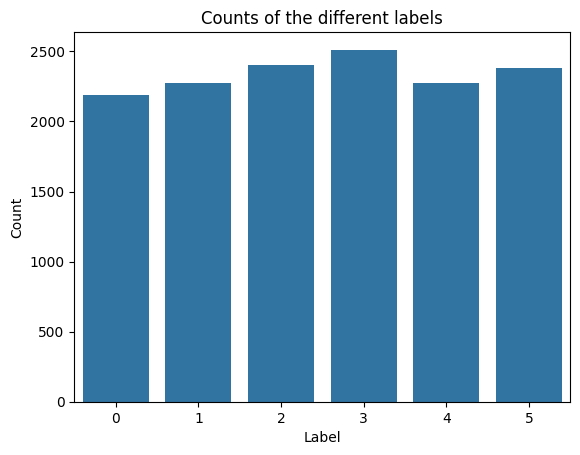

In [7]:
print(f"Images shape:  {images.shape}")
print(f"Labels shape:  {labels.shape}")

seaborn.countplot(x=labels.numpy())
plt.title("Counts of the different labels")
plt.ylabel("Count")
plt.xlabel("Label")
plt.show()

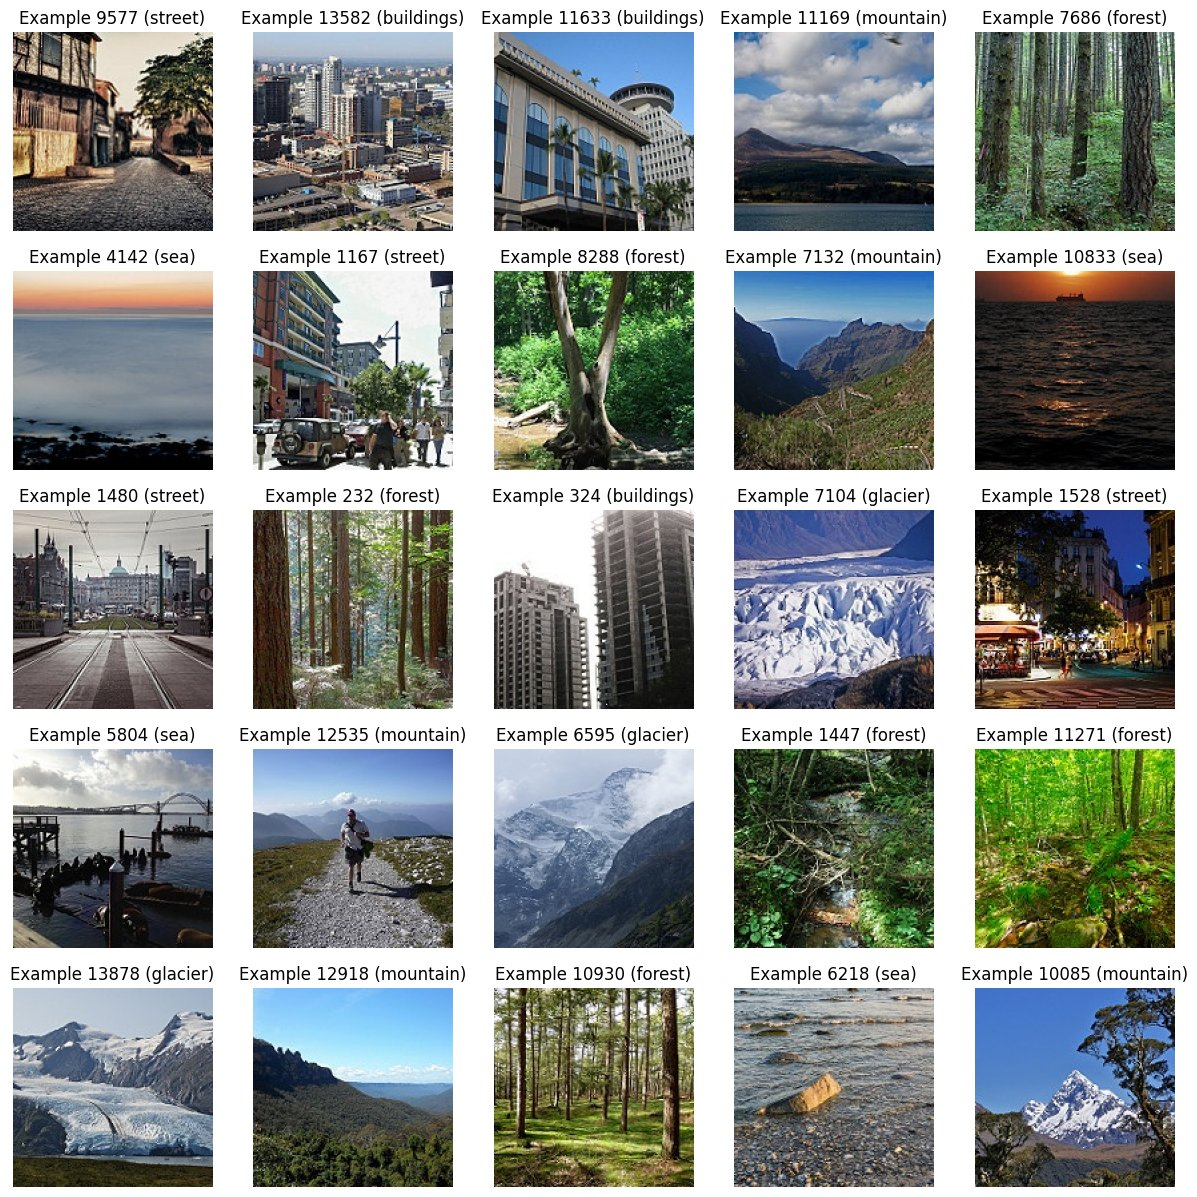

In [8]:
f, ax = plt.subplots(5, 5, figsize=(15, 15))

random_indexes = numpy.random.choice(images.shape[0],
                                     size=(5, 5),
                                     replace=False)

for i in range(5):
  for j in range(5):
    img_index = random_indexes[i, j]
    image = images[img_index]
    label = label_names[labels[img_index]]

    ax[i, j].imshow(image)
    ax[i, j].set_title(f"Example {img_index} ({label})")
    ax[i, j].axis('off')

## Model design

First, a “minimalistic” CNN

In [9]:
# Model initialization and definition

# The model is a stack of layers where the data flows sequentially
simple_cnn = keras.models.Sequential(name="simple_cnn")
simple_cnn.add(keras.layers.Input(shape=INPUT_SHAPE))
# A first layer of 1 convolution of 3x3 pixels
simple_cnn.add(keras.layers.Conv2D(1, kernel_size=(3, 3), activation="relu"))
# A max pooling layer
simple_cnn.add(keras.layers.MaxPool2D(3,3))

# A tensor manipulation layer: removes all dimensions
# except the batch one and another one holding all the values
simple_cnn.add(keras.layers.Flatten())

# A dense output layer with 6 neurons and a softmax activation
simple_cnn.add(keras.layers.Dense(6, activation="softmax"))

# Compile the model, defining the loss function
simple_cnn.compile(optimizer=keras.optimizers.Adam(learning_rate=0.0001),
                   loss="sparse_categorical_crossentropy",
                   metrics=["accuracy"])

# Display a summary of the model
simple_cnn.summary()

Model: "simple_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 1)    │            28 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 49, 49, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2401)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 6)              │        14,412 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,440 (56.41 KB)

 Trainable params: 14,440 (56.41 KB)

 Non-trainable params: 0 (0.00 B)

## Explaining the number of parameters

First convolution layer, with 1 kernel: kernel size × nb kernels × nb input channels + nb biases (= nb kernels) = 3 × 3 × 1 × 3 + 1 = 28

Last dense layer: input dim × output dim + nb biases = 2401 × 6 + 6

## Training

Let's train this model on our data! At first, we train for a single epoch, simply to check that our model works.

In [10]:
# Train the model
simple_cnn.fit(images, labels, epochs=1, validation_split=0.30)

307/307 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.2217 - loss: 98.3700 - val_accuracy: 0.2567 - val_loss: 71.7468


## Improving performance

In [11]:
CONV_LAYERS_NUMBER = 6
DENSE_LAYERS_SIZES = (200, 100, 50)


def conv() -> keras.layers.Conv2D:
  return keras.layers.Conv2D(filters=200,
                             kernel_size=(3,3),
                             activation="relu",
                             kernel_initializer="orthogonal",
                             padding="same")


def dense(size: int, activation: str = "relu") -> keras.layers.Dense:
  return keras.layers.Dense(size,
                            activation=activation,
                            kernel_initializer="orthogonal")


def dropout() -> keras.layers.Dropout:
  return keras.layers.Dropout(rate=0.2)


def max_pooling() -> keras.layers.MaxPooling2D:
  return keras.layers.MaxPooling2D(pool_size=(2, 2),
                                   strides=(2, 2),
                                   padding="same")


deep_cnn = keras.Sequential(name="deep_cnn")
deep_cnn.add(keras.layers.Input(shape=INPUT_SHAPE))

for _ in range(CONV_LAYERS_NUMBER - 1):
  deep_cnn.add(conv())
  deep_cnn.add(max_pooling())
deep_cnn.add(conv())

deep_cnn.add(keras.layers.Flatten())

for size in DENSE_LAYERS_SIZES:
  deep_cnn.add(dropout())
  deep_cnn.add(dense(size))

deep_cnn.add(dropout())
deep_cnn.add(dense(6, "softmax"))

deep_cnn.compile(optimizer=keras.optimizers.Adam(learning_rate=0.0001),
                 loss="sparse_categorical_crossentropy",
                 metrics=["accuracy"])

# Display a summary of the model
deep_cnn.summary()

Model: "deep_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 150, 150, 200)  │         5,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 75, 75, 200)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 75, 75, 200)    │       360,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 38, 38, 200)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 38, 38, 200)    │       360,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 19, 19, 200)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 19, 19, 200)    │       360,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 10, 10, 200)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 10, 10, 200)    │       360,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 5, 5, 200)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 5, 5, 200)      │       360,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 5000)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 5000)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 200)            │     1,000,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 200)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 100)            │        20,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 50)             │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 6)              │           306 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,832,256 (10.80 MB)

 Trainable params: 2,832,256 (10.80 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
# Visualize the training metrics
def plot_metrics(history) -> None:
  plt.plot(history["accuracy"])
  plt.plot(history["val_accuracy"])
  plt.title("Model accuracy")
  plt.ylabel("Accuracy")
  plt.xlabel("Epoch")
  plt.legend(["Training", "Validation"], loc="upper left")
  plt.show()

  plt.plot(history["loss"])
  plt.plot(history["val_loss"])
  plt.title("Model loss")
  plt.ylabel("Loss")
  plt.xlabel("Epoch")
  plt.legend(["Training", "Validation"], loc="upper right")
  plt.show()

Epoch 1/15
77/77 ━━━━━━━━━━━━━━━━━━━━ 162s 2s/step - accuracy: 0.3327 - loss: 1.7272 - val_accuracy: 0.5417 - val_loss: 1.2358
Epoch 2/15
77/77 ━━━━━━━━━━━━━━━━━━━━ 98s 712ms/step - accuracy: 0.5051 - loss: 1.2514 - val_accuracy: 0.6046 - val_loss: 1.0301
Epoch 3/15
77/77 ━━━━━━━━━━━━━━━━━━━━ 82s 716ms/step - accuracy: 0.5887 - loss: 1.0759 - val_accuracy: 0.6742 - val_loss: 0.8907
Epoch 4/15
77/77 ━━━━━━━━━━━━━━━━━━━━ 56s 724ms/step - accuracy: 0.6323 - loss: 0.9763 - val_accuracy: 0.6903 - val_loss: 0.8160
Epoch 5/15
77/77 ━━━━━━━━━━━━━━━━━━━━ 56s 734ms/step - accuracy: 0.6855 - loss: 0.8619 - val_accuracy: 0.7245 - val_loss: 0.7450
Epoch 6/15
77/77 ━━━━━━━━━━━━━━━━━━━━ 56s 729ms/step - accuracy: 0.7005 - loss: 0.8161 - val_accuracy: 0.7587 - val_loss: 0.6773
Epoch 7/15
77/77 ━━━━━━━━━━━━━━━━━━━━ 56s 728ms/step - accuracy: 0.7348 - loss: 0.7520 - val_accuracy: 0.7542 - val_loss: 0.6893
Epoch 8/15
77/77 ━━━━━━━━━━━━━━━━━━━━ 56s 731ms/step - accuracy: 0.7633 - loss: 0.6767 - val_accura

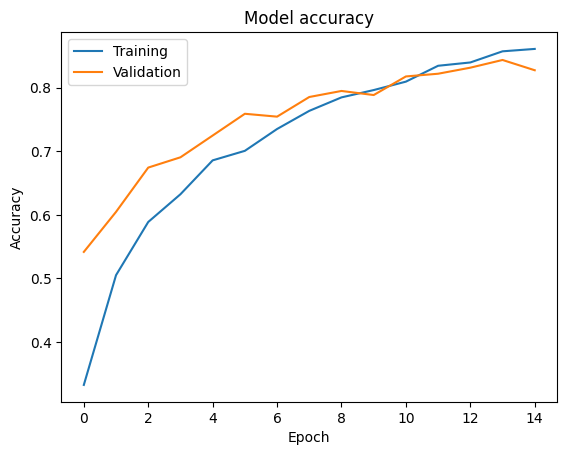

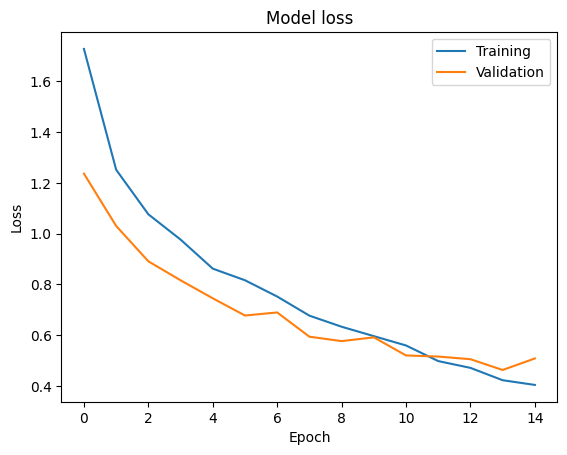

In [13]:
# Train the model

BEST_DEEP_MODEL_PATH = "best_deep_model.weights.h5"

early_stopping = keras.callbacks.EarlyStopping(
    patience=5,
    monitor="val_loss")

model_checkpoint = keras.callbacks.ModelCheckpoint(
    filepath=BEST_DEEP_MODEL_PATH,
    monitor="val_accuracy",
    mode="max",
    save_weights_only=True,
    save_best_only=True)

training = deep_cnn.fit(images,
                        labels,
                        epochs=DEEP_CNN_EPOCHS,
                        validation_split=0.30,
                        batch_size=128,
                        callbacks=[early_stopping, model_checkpoint])

deep_cnn.load_weights(BEST_DEEP_MODEL_PATH)

plot_metrics(training.history)

## Evaluating the Performance on the Test Set

The `seg_test` folder contains a dataset never seen during training.

We'll use the model's `evaluate(X, y)` method to evaluate the quality of our predictions on this dataset.

In [14]:
test_images,test_labels = get_images(
    pathlib.Path("landscape") / "seg_test")
loss, accuracy = deep_cnn.evaluate(test_images, test_labels, verbose=False)
print(f"Loss: {loss:.2f}, accuracy: {accuracy:.2f}")

Processing folders:   0%|          | 0/6 [00:00<?, ?it/s]

Folder buildings:   0%|          | 0/437 [00:00<?, ?it/s]

Folder forest:   0%|          | 0/474 [00:00<?, ?it/s]

Folder glacier:   0%|          | 0/553 [00:00<?, ?it/s]

Folder mountain:   0%|          | 0/525 [00:00<?, ?it/s]

Folder sea:   0%|          | 0/510 [00:00<?, ?it/s]

Folder street:   0%|          | 0/501 [00:00<?, ?it/s]

Loss: 0.47, accuracy: 0.84


## Error Analysis

We display the confusion matrix, then look at misclassified images.

In [15]:
def predict(model: keras.Model, images: tf.Tensor) -> tf.Tensor:
  return tf.math.argmax(model.predict(images), axis=-1)


def analyze_preds(preds: tf.Tensor, labels: tf.Tensor) -> None:
  confusion_matrix = sklearn.metrics.confusion_matrix(labels, preds)
  seaborn.heatmap(confusion_matrix,
                  cmap="rocket_r",
                  xticklabels=label_names,
                  yticklabels=label_names,
                  annot=True,
                  fmt="d")
  plt.title("Confusion matrix")
  plt.show()

  seaborn.countplot(x=[label_names[x] for x in preds])
  plt.title("Counts of the predicted classes")
  plt.ylabel("Count")
  plt.xlabel("Class")
  plt.show()

94/94 ━━━━━━━━━━━━━━━━━━━━ 5s 48ms/step


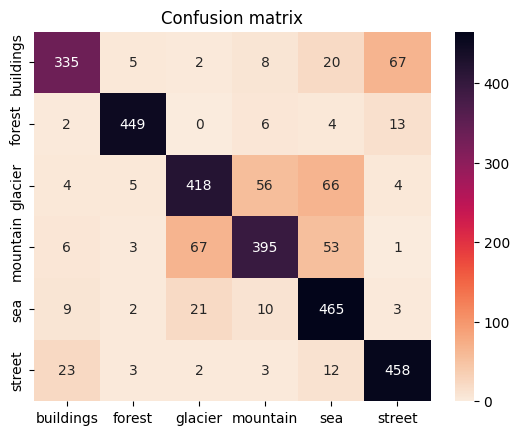

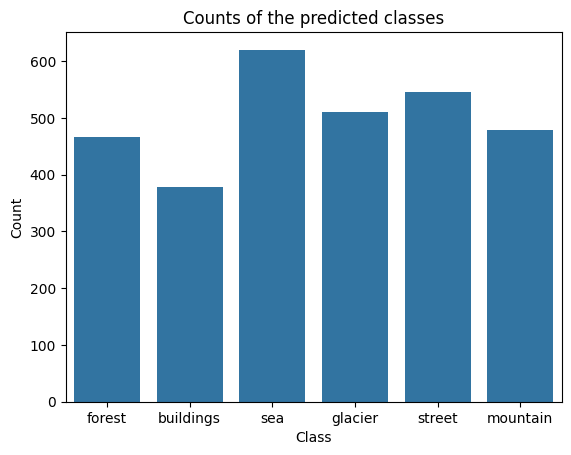

In [16]:
test_preds = predict(deep_cnn, test_images)
analyze_preds(test_preds, test_labels)

In [17]:
def plot_mistakes(predicted_class: str,
                  true_class: str,
                  images: tf.Tensor,
                  preds: tf.Tensor,
                  labels: tf.Tensor
                  ) -> None:
  print(f"Prediction: {predicted_class}, true class: {true_class}")
  mistakes = images[(preds == label_to_index[predicted_class])
                         & (labels == label_to_index[true_class])]
  random_indexes = numpy.random.choice(mistakes.shape[0],
                                       size=min(mistakes.shape[0], 25),
                                       replace=False)
  grid_indexes = itertools.product(range(5), repeat=2)

  if mistakes.shape[1] == 3:
    mistakes = tf.transpose(mistakes, perm=(0, 2, 3, 1))

  _, ax = plt.subplots(5, 5, figsize=(15, 15))
  for img_index, (i, j) in zip(random_indexes, grid_indexes):
    ax[i, j].imshow(mistakes[img_index])
    ax[i, j].axis("off")
  plt.show()

Prediction: glacier, true class: mountain


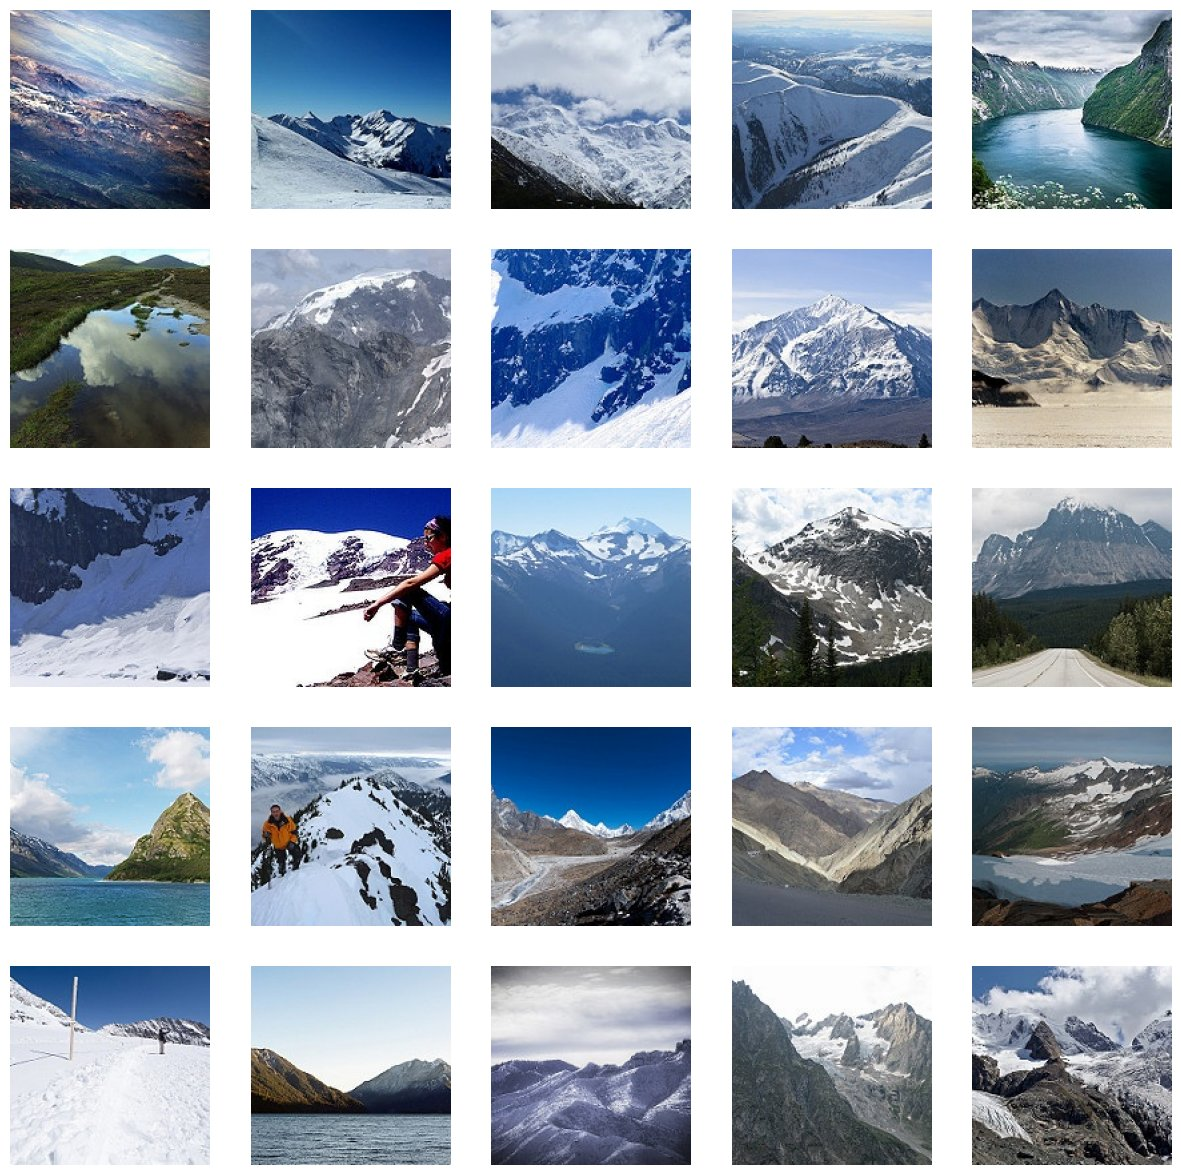

In [18]:
# Plot the images predicted as glacier while their label is mountain
plot_mistakes("glacier", "mountain", test_images, test_preds, test_labels)

Prediction: glacier, true class: sea


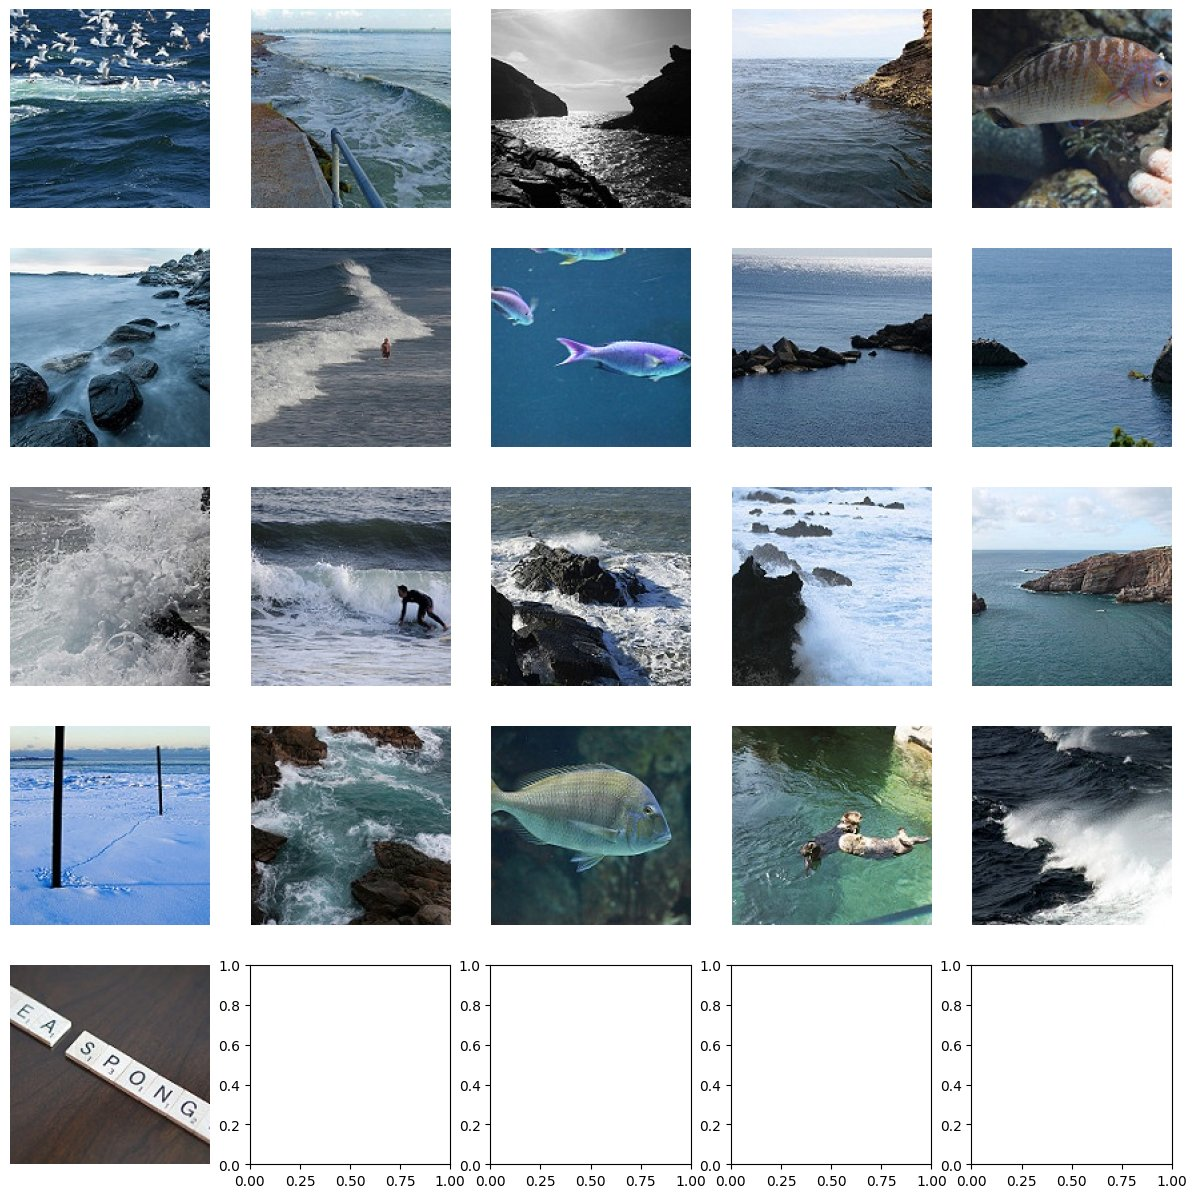

In [19]:
# Plot the images predicted as glacier while their label is sea
plot_mistakes("glacier", "sea", test_images, test_preds, test_labels)

Prediction: buildings, true class: sea


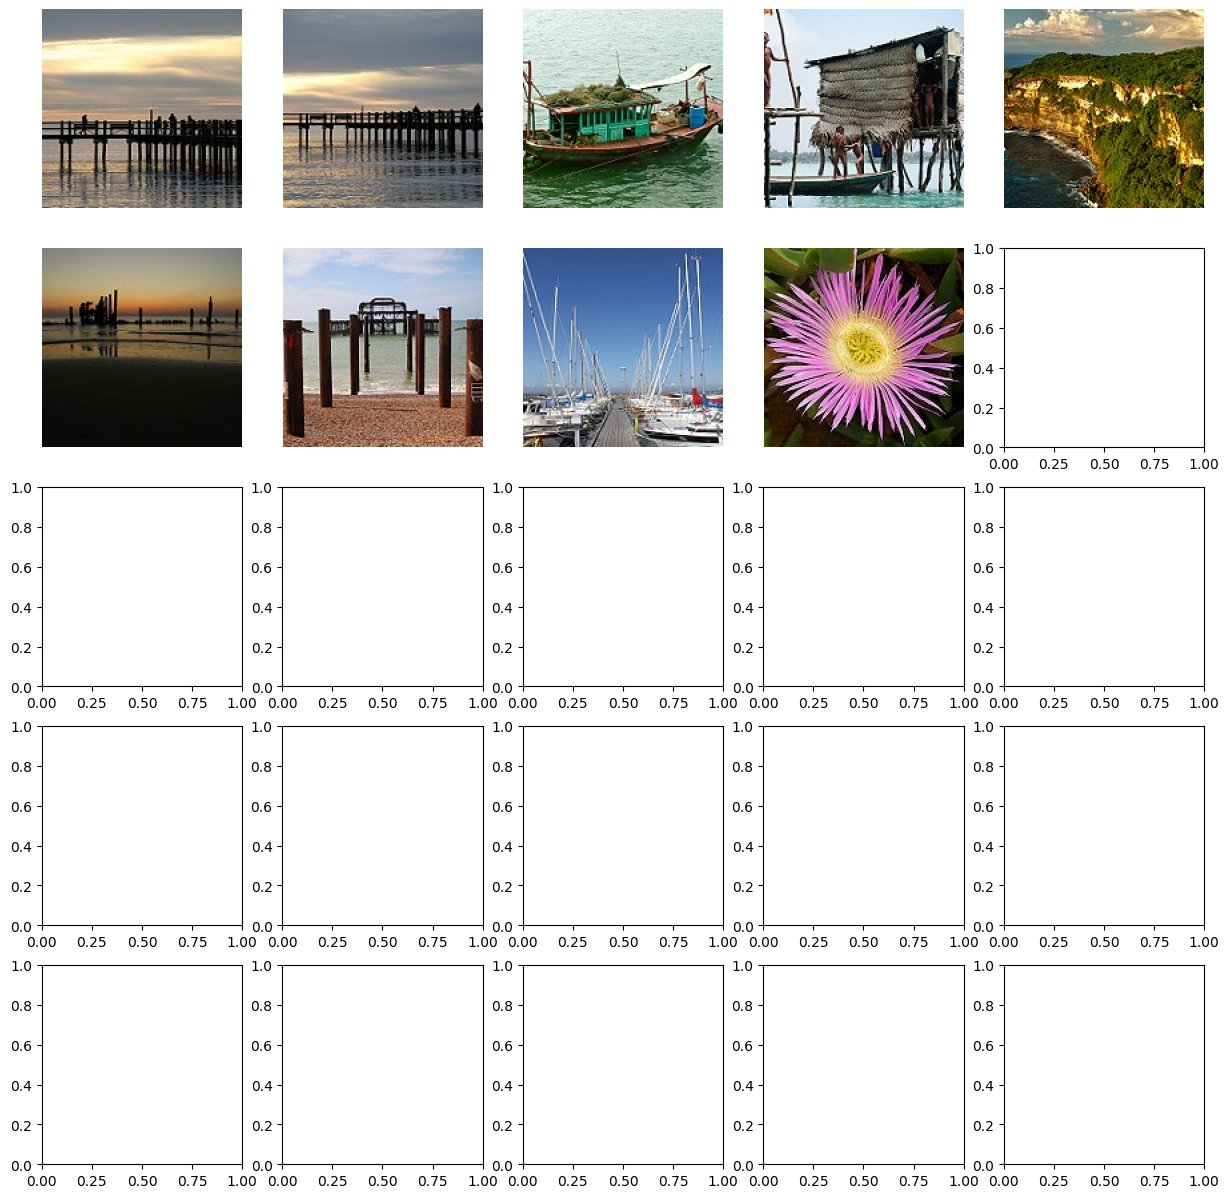

In [20]:
# Plot the images predicted as buildings while their label is sea
plot_mistakes("buildings", "sea", test_images, test_preds, test_labels)

In [21]:
def evaluate(model: keras.Model, images: tf.Tensor, labels: tf.Tensor) -> None:
  loss, accuracy = model.evaluate(images, labels, verbose=False)
  print(f"Loss: {loss:.2f}, accuracy: {accuracy:.2f}")
  preds = predict(model, images)
  analyze_preds(preds, labels)
  plot_mistakes("glacier", "mountain", images, preds, labels)
  plot_mistakes("glacier", "sea", images, preds, labels)
  plot_mistakes("buildings", "sea", images, preds, labels)

Loss: 0.47, accuracy: 0.84
94/94 ━━━━━━━━━━━━━━━━━━━━ 4s 42ms/step


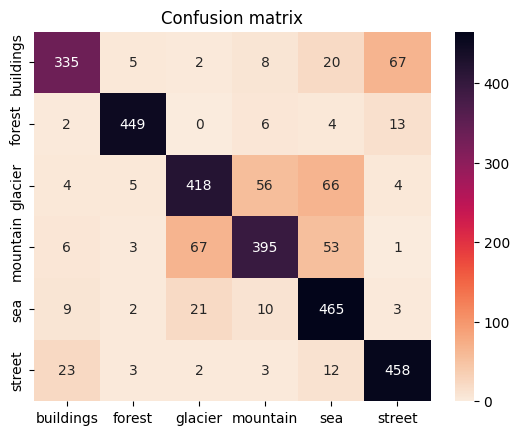

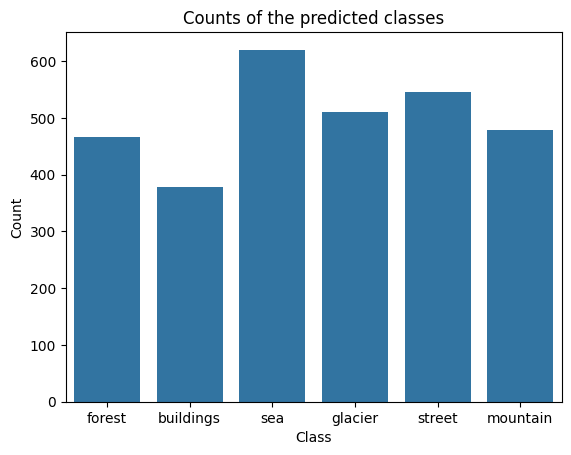

Prediction: glacier, true class: mountain


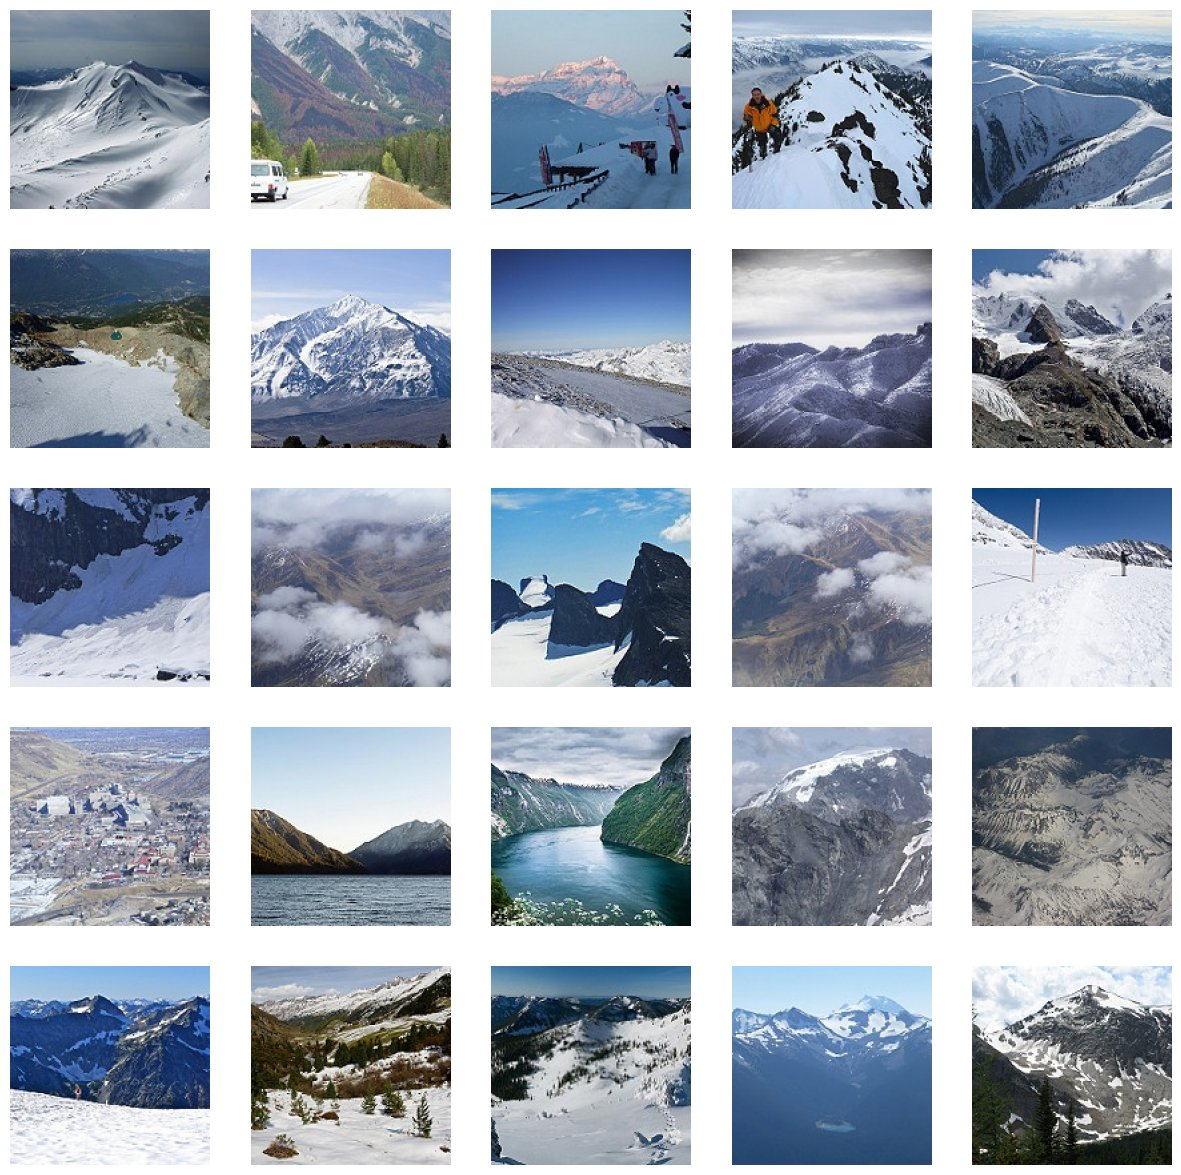

Prediction: glacier, true class: sea


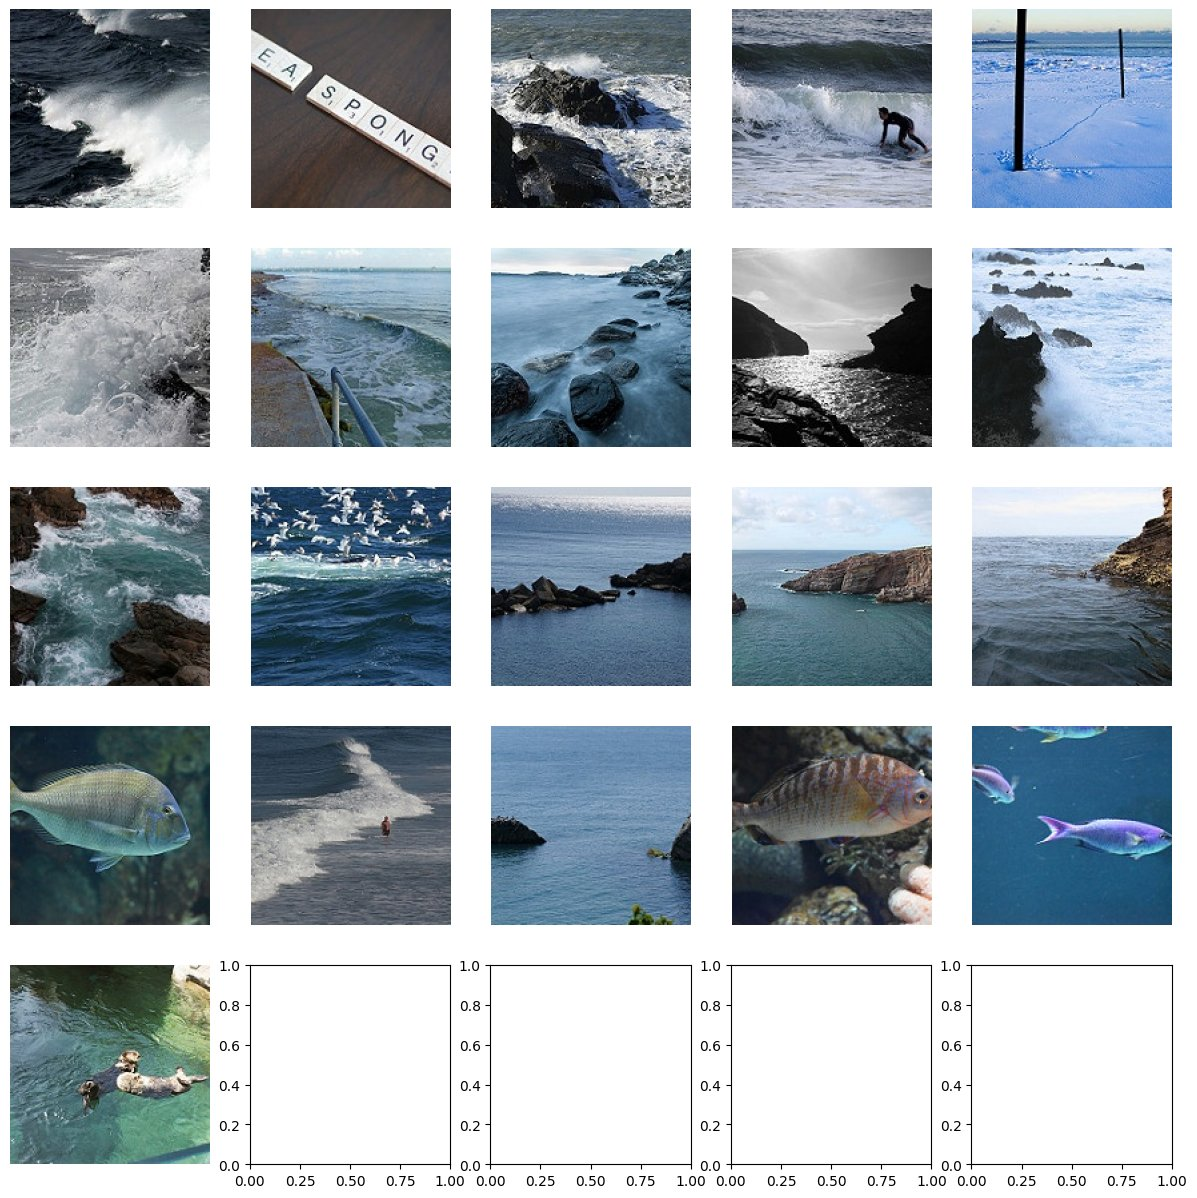

Prediction: buildings, true class: sea


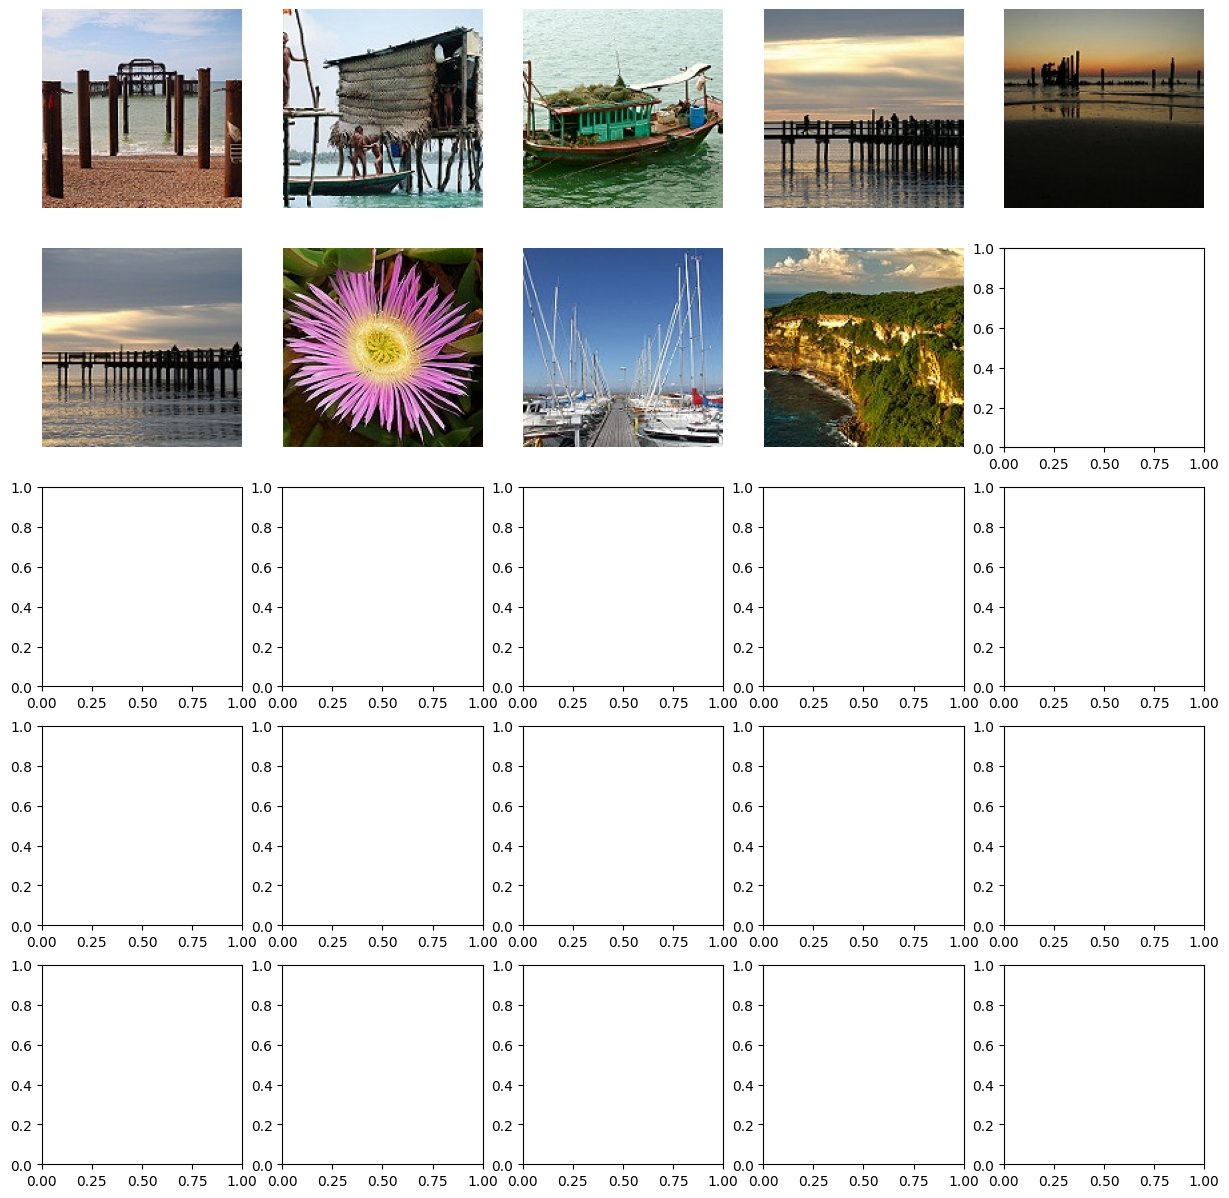

In [22]:
evaluate(deep_cnn, test_images, test_labels)

## Transfer Learning

In [23]:
base_model = keras.applications.EfficientNetV2B0(include_top=False,
                                                 weights="imagenet",
                                                 input_shape=(150, 150, 3))

base_model.trainable = False

transferred_cnn = keras.Sequential(
    [base_model,
     keras.layers.SpatialDropout2D(0.1),
     keras.layers.Conv2D(1024, 1, activation="relu"),
     keras.layers.SpatialDropout2D(0.1),
     keras.layers.Conv2D(256, 1, activation="relu"),
     keras.layers.SpatialDropout2D(0.1),
     keras.layers.Conv2D(64, 1, activation="relu"),
     keras.layers.SpatialDropout2D(0.1),
     keras.layers.Conv2D(16, 1, activation="relu"),
     keras.layers.SpatialDropout2D(0.1),
     keras.layers.Flatten(),
     keras.layers.Dense(6, activation="softmax", kernel_regularizer="l2")],
    name="transferred_cnn")

transferred_cnn.compile(optimizer=keras.optimizers.Adam(learning_rate=0.0001),
                        loss="sparse_categorical_crossentropy",
                        metrics=["accuracy"])

transferred_cnn.summary()

Model: "transferred_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetv2-b0 (Functional)  │ (None, 5, 5, 1280)     │     5,919,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout2d               │ (None, 5, 5, 1280)     │             0 │
│ (SpatialDropout2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 5, 5, 1024)     │     1,311,744 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout2d_1             │ (None, 5, 5, 1024)     │             0 │
│ (SpatialDropout2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 5, 5, 256)      │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout2d_2             │ (None, 5, 5, 256)      │             0 │
│ (SpatialDropout2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 5, 5, 64)       │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout2d_3             │ (None, 5, 5, 64)       │             0 │
│ (SpatialDropout2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 5, 5, 16)       │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout2d_4             │ (None, 5, 5, 16)       │             0 │
│ (SpatialDropout2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 400)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 6)              │         2,406 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,513,350 (28.66 MB)

 Trainable params: 1,594,038 (6.08 MB)

 Non-trainable params: 5,919,312 (22.58 MB)

In [24]:
training = transferred_cnn.fit(images,
                               labels,
                               epochs=5,
                               validation_split=0.30,
                               batch_size=512)

Epoch 1/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 99s 3s/step - accuracy: 0.3842 - loss: 1.6865 - val_accuracy: 0.6763 - val_loss: 1.2381
Epoch 2/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 61s 300ms/step - accuracy: 0.6855 - loss: 1.0448 - val_accuracy: 0.8347 - val_loss: 0.6400
Epoch 3/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 295ms/step - accuracy: 0.8068 - loss: 0.6783 - val_accuracy: 0.8718 - val_loss: 0.4771
Epoch 4/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 298ms/step - accuracy: 0.8495 - loss: 0.5478 - val_accuracy: 0.8882 - val_loss: 0.4281
Epoch 5/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 302ms/step - accuracy: 0.8683 - loss: 0.4819 - val_accuracy: 0.8965 - val_loss: 0.4053


Loss: 0.42, accuracy: 0.89
94/94 ━━━━━━━━━━━━━━━━━━━━ 14s 83ms/step


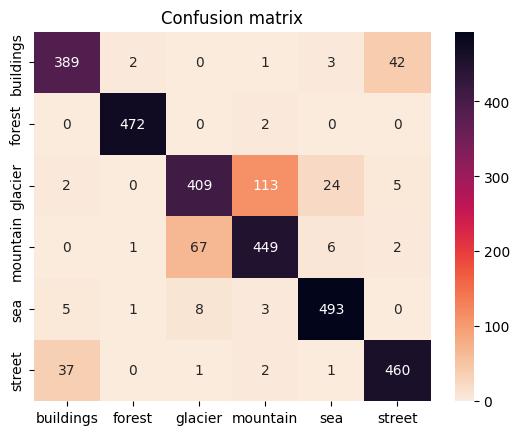

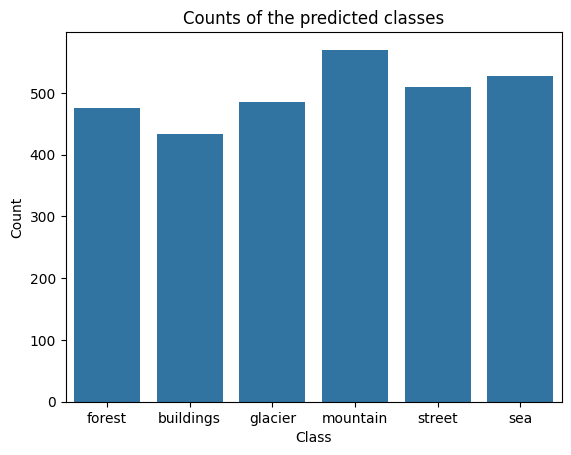

Prediction: glacier, true class: mountain


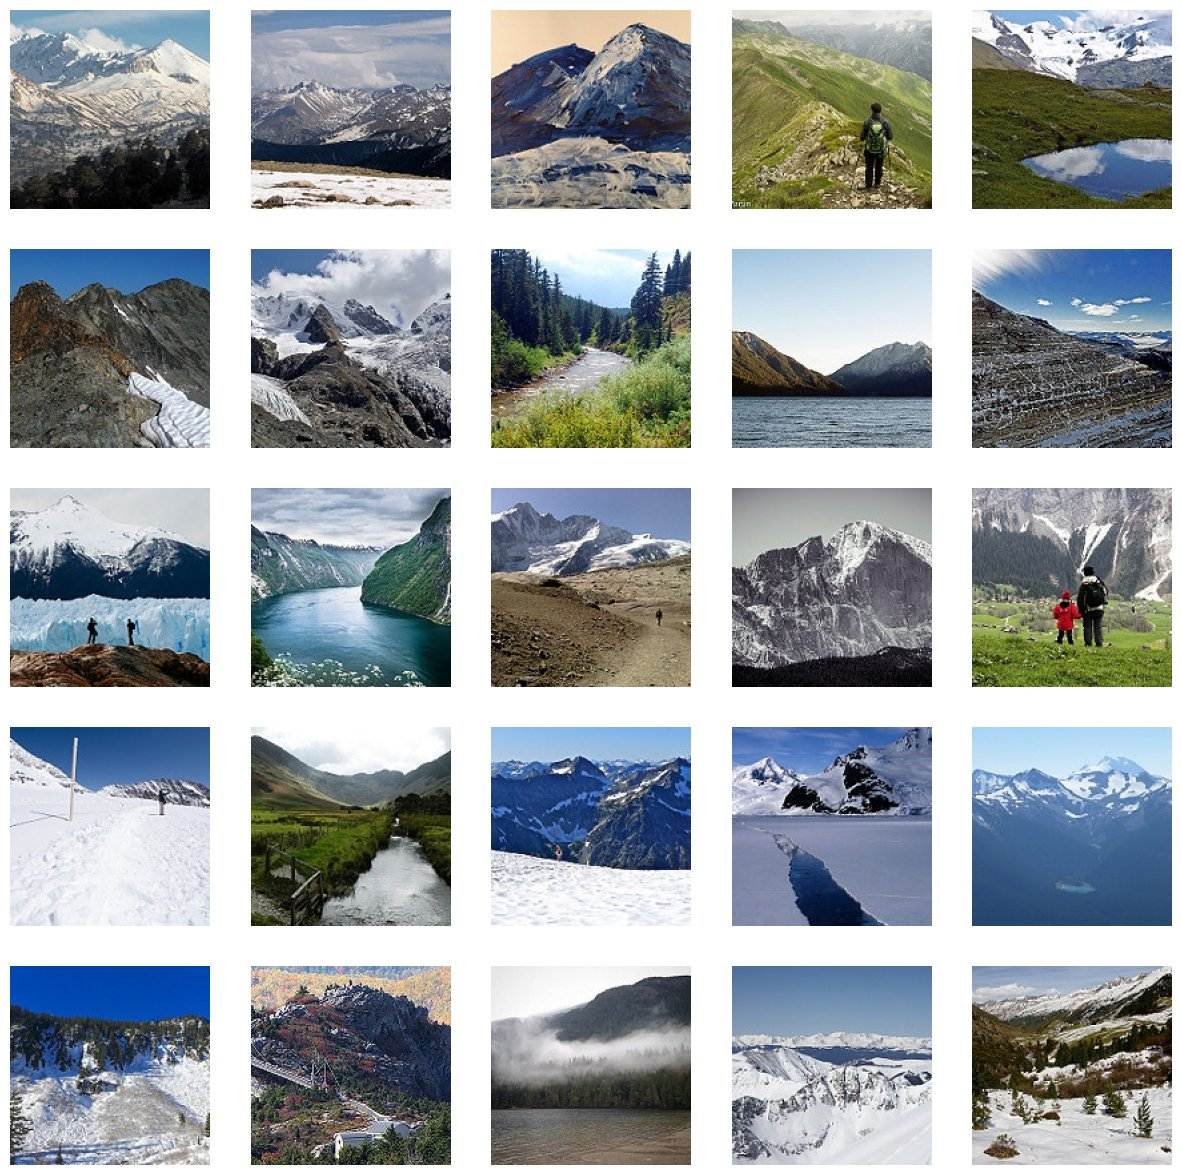

Prediction: glacier, true class: sea


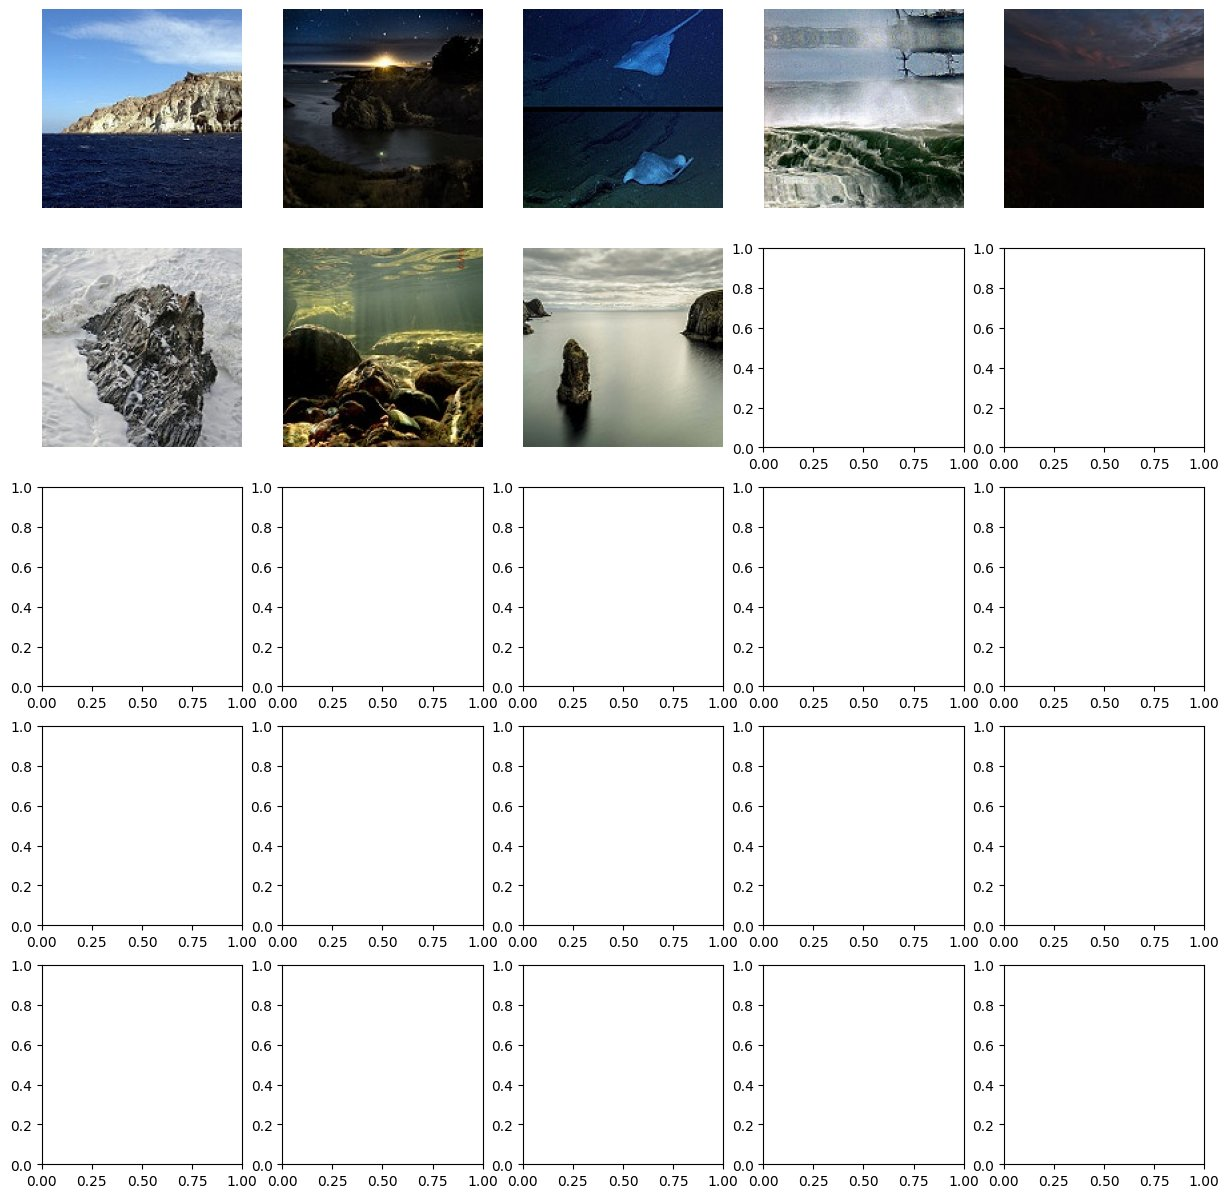

Prediction: buildings, true class: sea


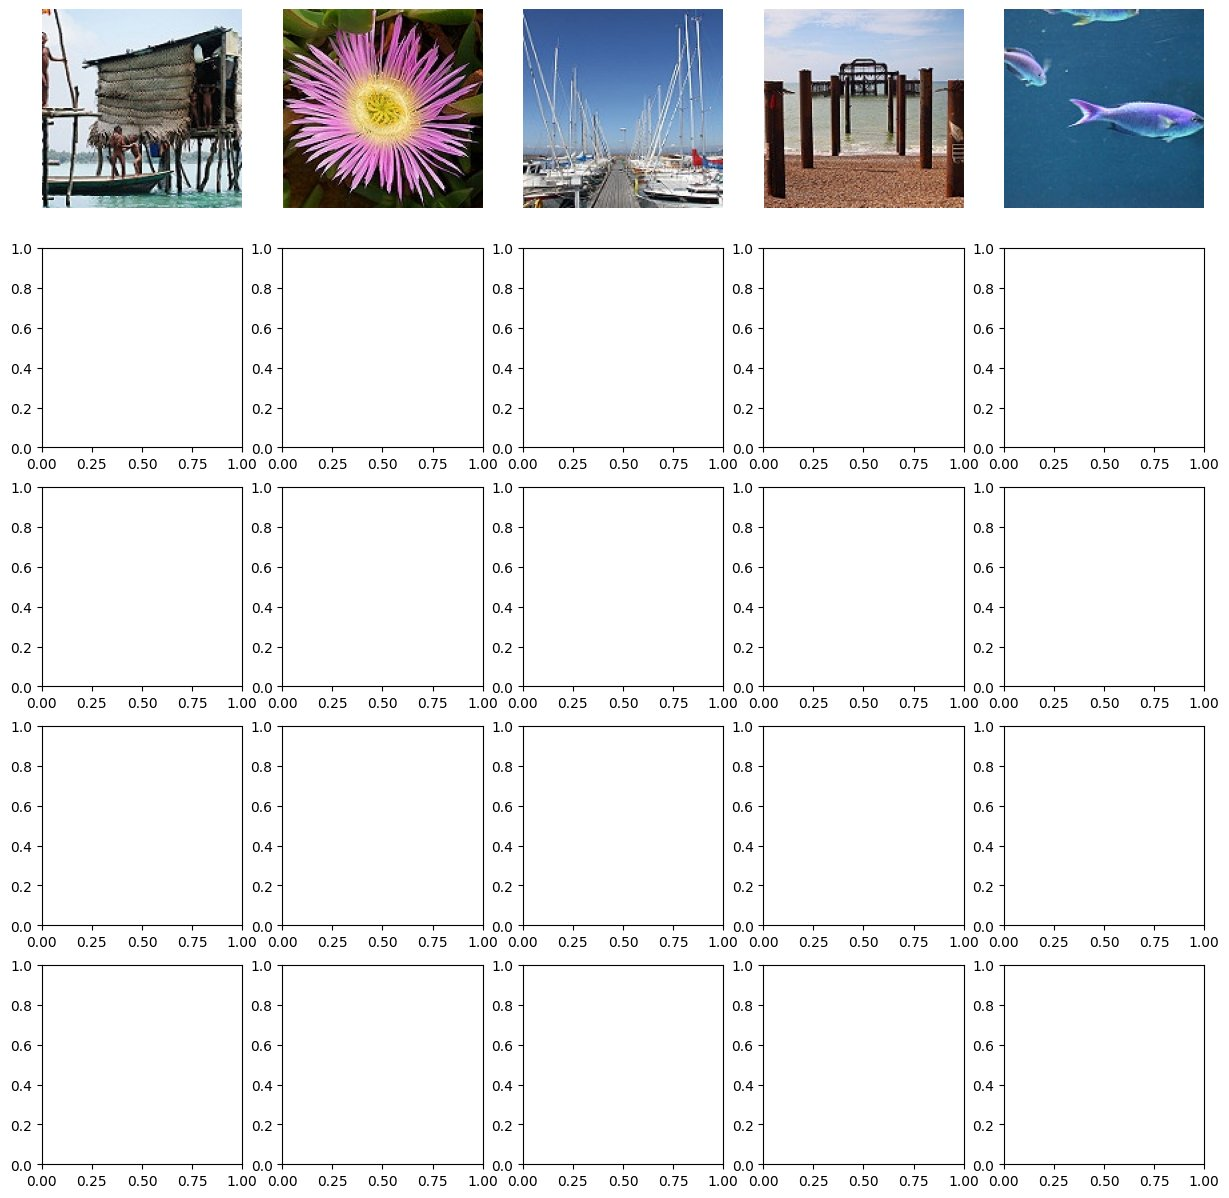

In [25]:
evaluate(transferred_cnn, test_images, test_labels)

## With transformers for computer vision (ViT)

In [26]:
!pip install 'transformers < 5'

In [27]:
images, labels = get_images(pathlib.Path("landscape") / "seg_train",
                            size=224,
                            channels_first=True)

Processing folders:   0%|          | 0/6 [00:00<?, ?it/s]

Folder buildings:   0%|          | 0/2191 [00:00<?, ?it/s]

Folder forest:   0%|          | 0/2271 [00:00<?, ?it/s]

Folder glacier:   0%|          | 0/2404 [00:00<?, ?it/s]

Folder mountain:   0%|          | 0/2512 [00:00<?, ?it/s]

Folder sea:   0%|          | 0/2274 [00:00<?, ?it/s]

Folder street:   0%|          | 0/2382 [00:00<?, ?it/s]

In [28]:
import transformers


vit = transformers.TFAutoModel.from_pretrained(
    "google/vit-base-patch16-224-in21k", use_safetensors=False)

vit.trainable = False
inputs = keras.layers.Input((3, 224, 224))
x = keras.layers.Lambda(lambda t: t / 255)(inputs)
x = keras.layers.Normalization(mean=0.5, variance=0.5 ** 2)(x)

# Wrap the vit model call in a Lambda layer to handle the tensor type issue
x = keras.layers.Lambda(lambda x: vit(x).last_hidden_state)(x)

x = keras.layers.Dense(128, activation="relu")(x)
x = keras.layers.Dense(64, activation="relu")(x)
x = keras.layers.Dense(32, activation="relu")(x)
x = keras.layers.Flatten()(x)
outputs = keras.layers.Dense(6, activation="softmax")(x)
transferred_transformer = keras.Model(inputs=inputs,
                                      outputs=outputs,
                                      name="transferred_transformer")
transferred_transformer.compile(optimizer="adam",
                                metrics=["accuracy"],
                                loss="sparse_categorical_crossentropy")
transferred_transformer.summary()

/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(
TensorFlow and JAX classes are deprecated and will be removed in Transformers v5. We recommend migrating to PyTorch classes or pinning your version of Transformers.
All model checkpoint layers were used when initializing TFViTModel.

All the layers of TFViTModel were initialized from the model checkpoint at google/vit-base-patch16-224-in21k.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFViTModel for predictions without further training.


Model: "transferred_transformer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 3, 224, 224)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (None, 3, 224, 224)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ normalization_1 (Normalization) │ (None, 3, 224, 224)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda_1 (Lambda)               │ (None, 197, 768)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 197, 128)       │        98,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 197, 64)        │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 197, 32)        │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 6304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 6)              │        37,830 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 146,598 (572.65 KB)

 Trainable params: 146,598 (572.65 KB)

 Non-trainable params: 0 (0.00 B)

In [29]:
transferred_transformer.fit(images, labels, epochs=VIT_EPOCHS, validation_split=0.3, batch_size=512)

Epoch 1/3
20/20 ━━━━━━━━━━━━━━━━━━━━ 189s 8s/step - accuracy: 0.7970 - loss: 0.6332 - val_accuracy: 0.8941 - val_loss: 0.3529
Epoch 2/3
20/20 ━━━━━━━━━━━━━━━━━━━━ 136s 7s/step - accuracy: 0.9346 - loss: 0.2047 - val_accuracy: 0.9311 - val_loss: 0.2219
Epoch 3/3
20/20 ━━━━━━━━━━━━━━━━━━━━ 136s 7s/step - accuracy: 0.9556 - loss: 0.1238 - val_accuracy: 0.9373 - val_loss: 0.1879


Processing folders:   0%|          | 0/6 [00:00<?, ?it/s]

Folder buildings:   0%|          | 0/437 [00:00<?, ?it/s]

Folder forest:   0%|          | 0/474 [00:00<?, ?it/s]

Folder glacier:   0%|          | 0/553 [00:00<?, ?it/s]

Folder mountain:   0%|          | 0/525 [00:00<?, ?it/s]

Folder sea:   0%|          | 0/510 [00:00<?, ?it/s]

Folder street:   0%|          | 0/501 [00:00<?, ?it/s]

Loss: 0.18, accuracy: 0.94
94/94 ━━━━━━━━━━━━━━━━━━━━ 42s 411ms/step


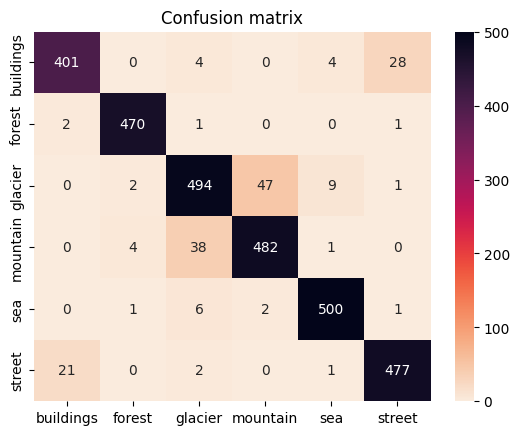

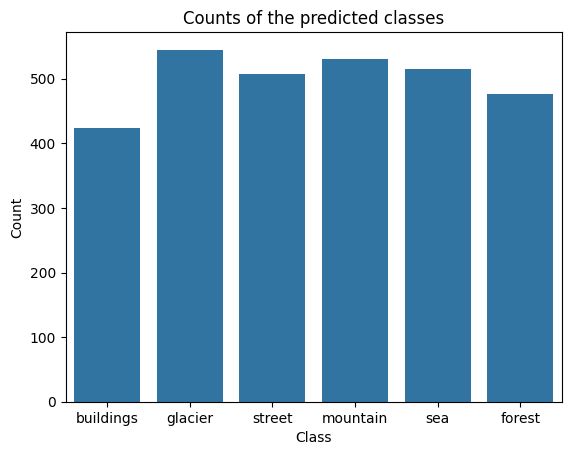

Prediction: glacier, true class: mountain


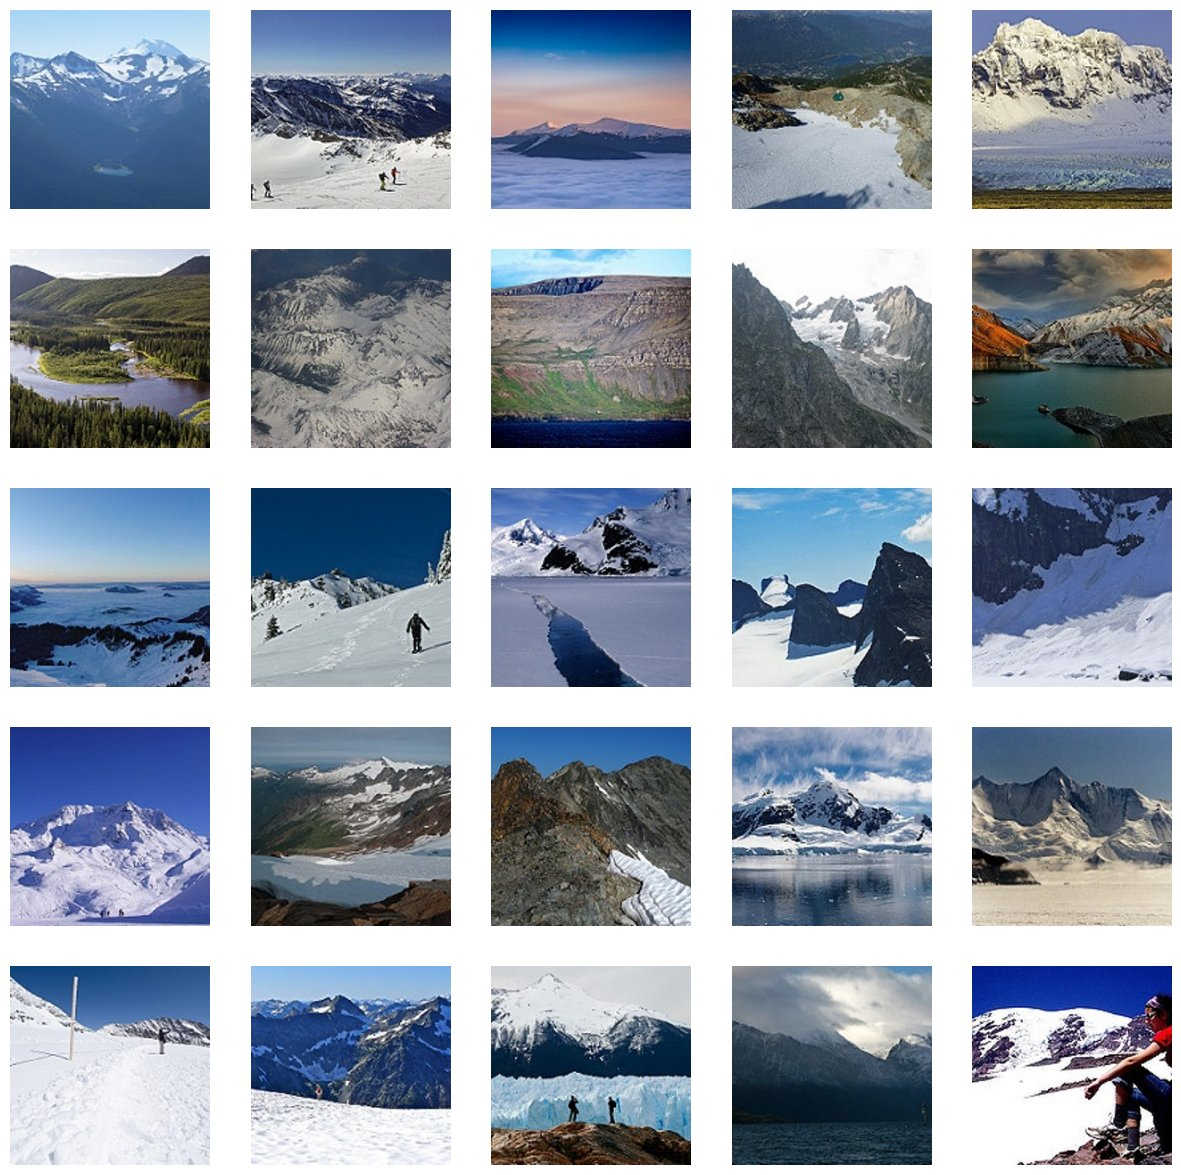

Prediction: glacier, true class: sea


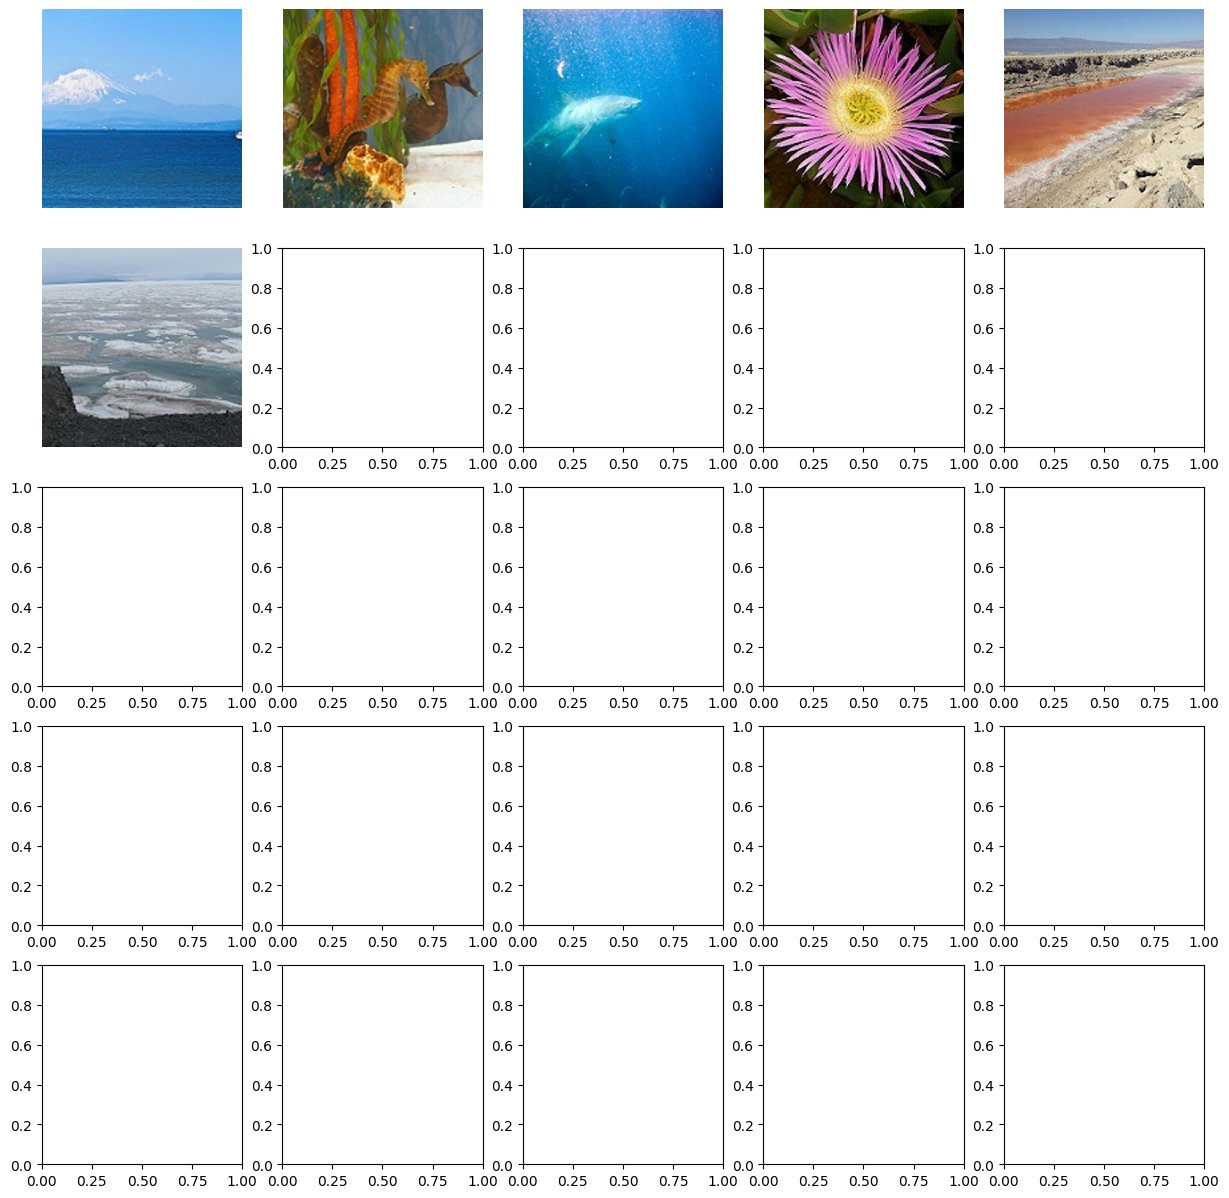

Prediction: buildings, true class: sea


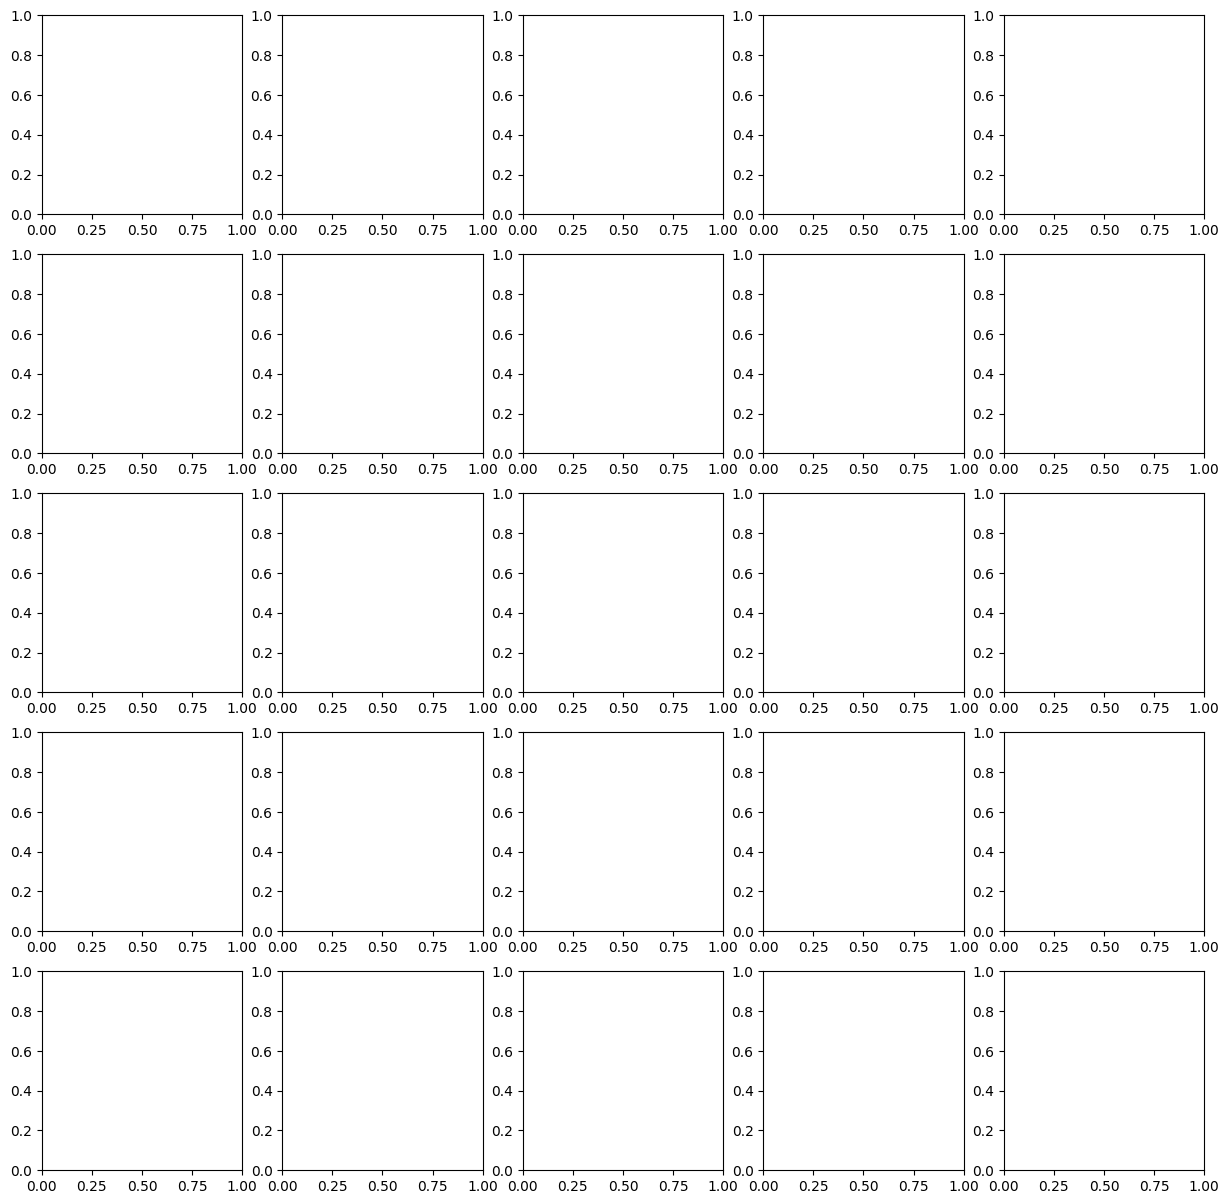

In [30]:
test_images, test_labels = get_images(
    pathlib.Path("landscape") / "seg_test",
    size=224,
    channels_first=True)
evaluate(transferred_transformer, test_images, test_labels)

## Predicting in "Real" Conditions

The `seg_pred` folder contains unannotated images. We therefore can't properly evaluate the performance on this set.

However, we can display photos and the probabilities our model assigns to each class.

In [31]:
pred_images = get_images(
    pathlib.Path("landscape") / "seg_pred",
    size=224,
    channels_first=True,
    create_labels=False)

Processing folders:   0%|          | 0/1 [00:00<?, ?it/s]

Folder no_supervision:   0%|          | 0/7301 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step


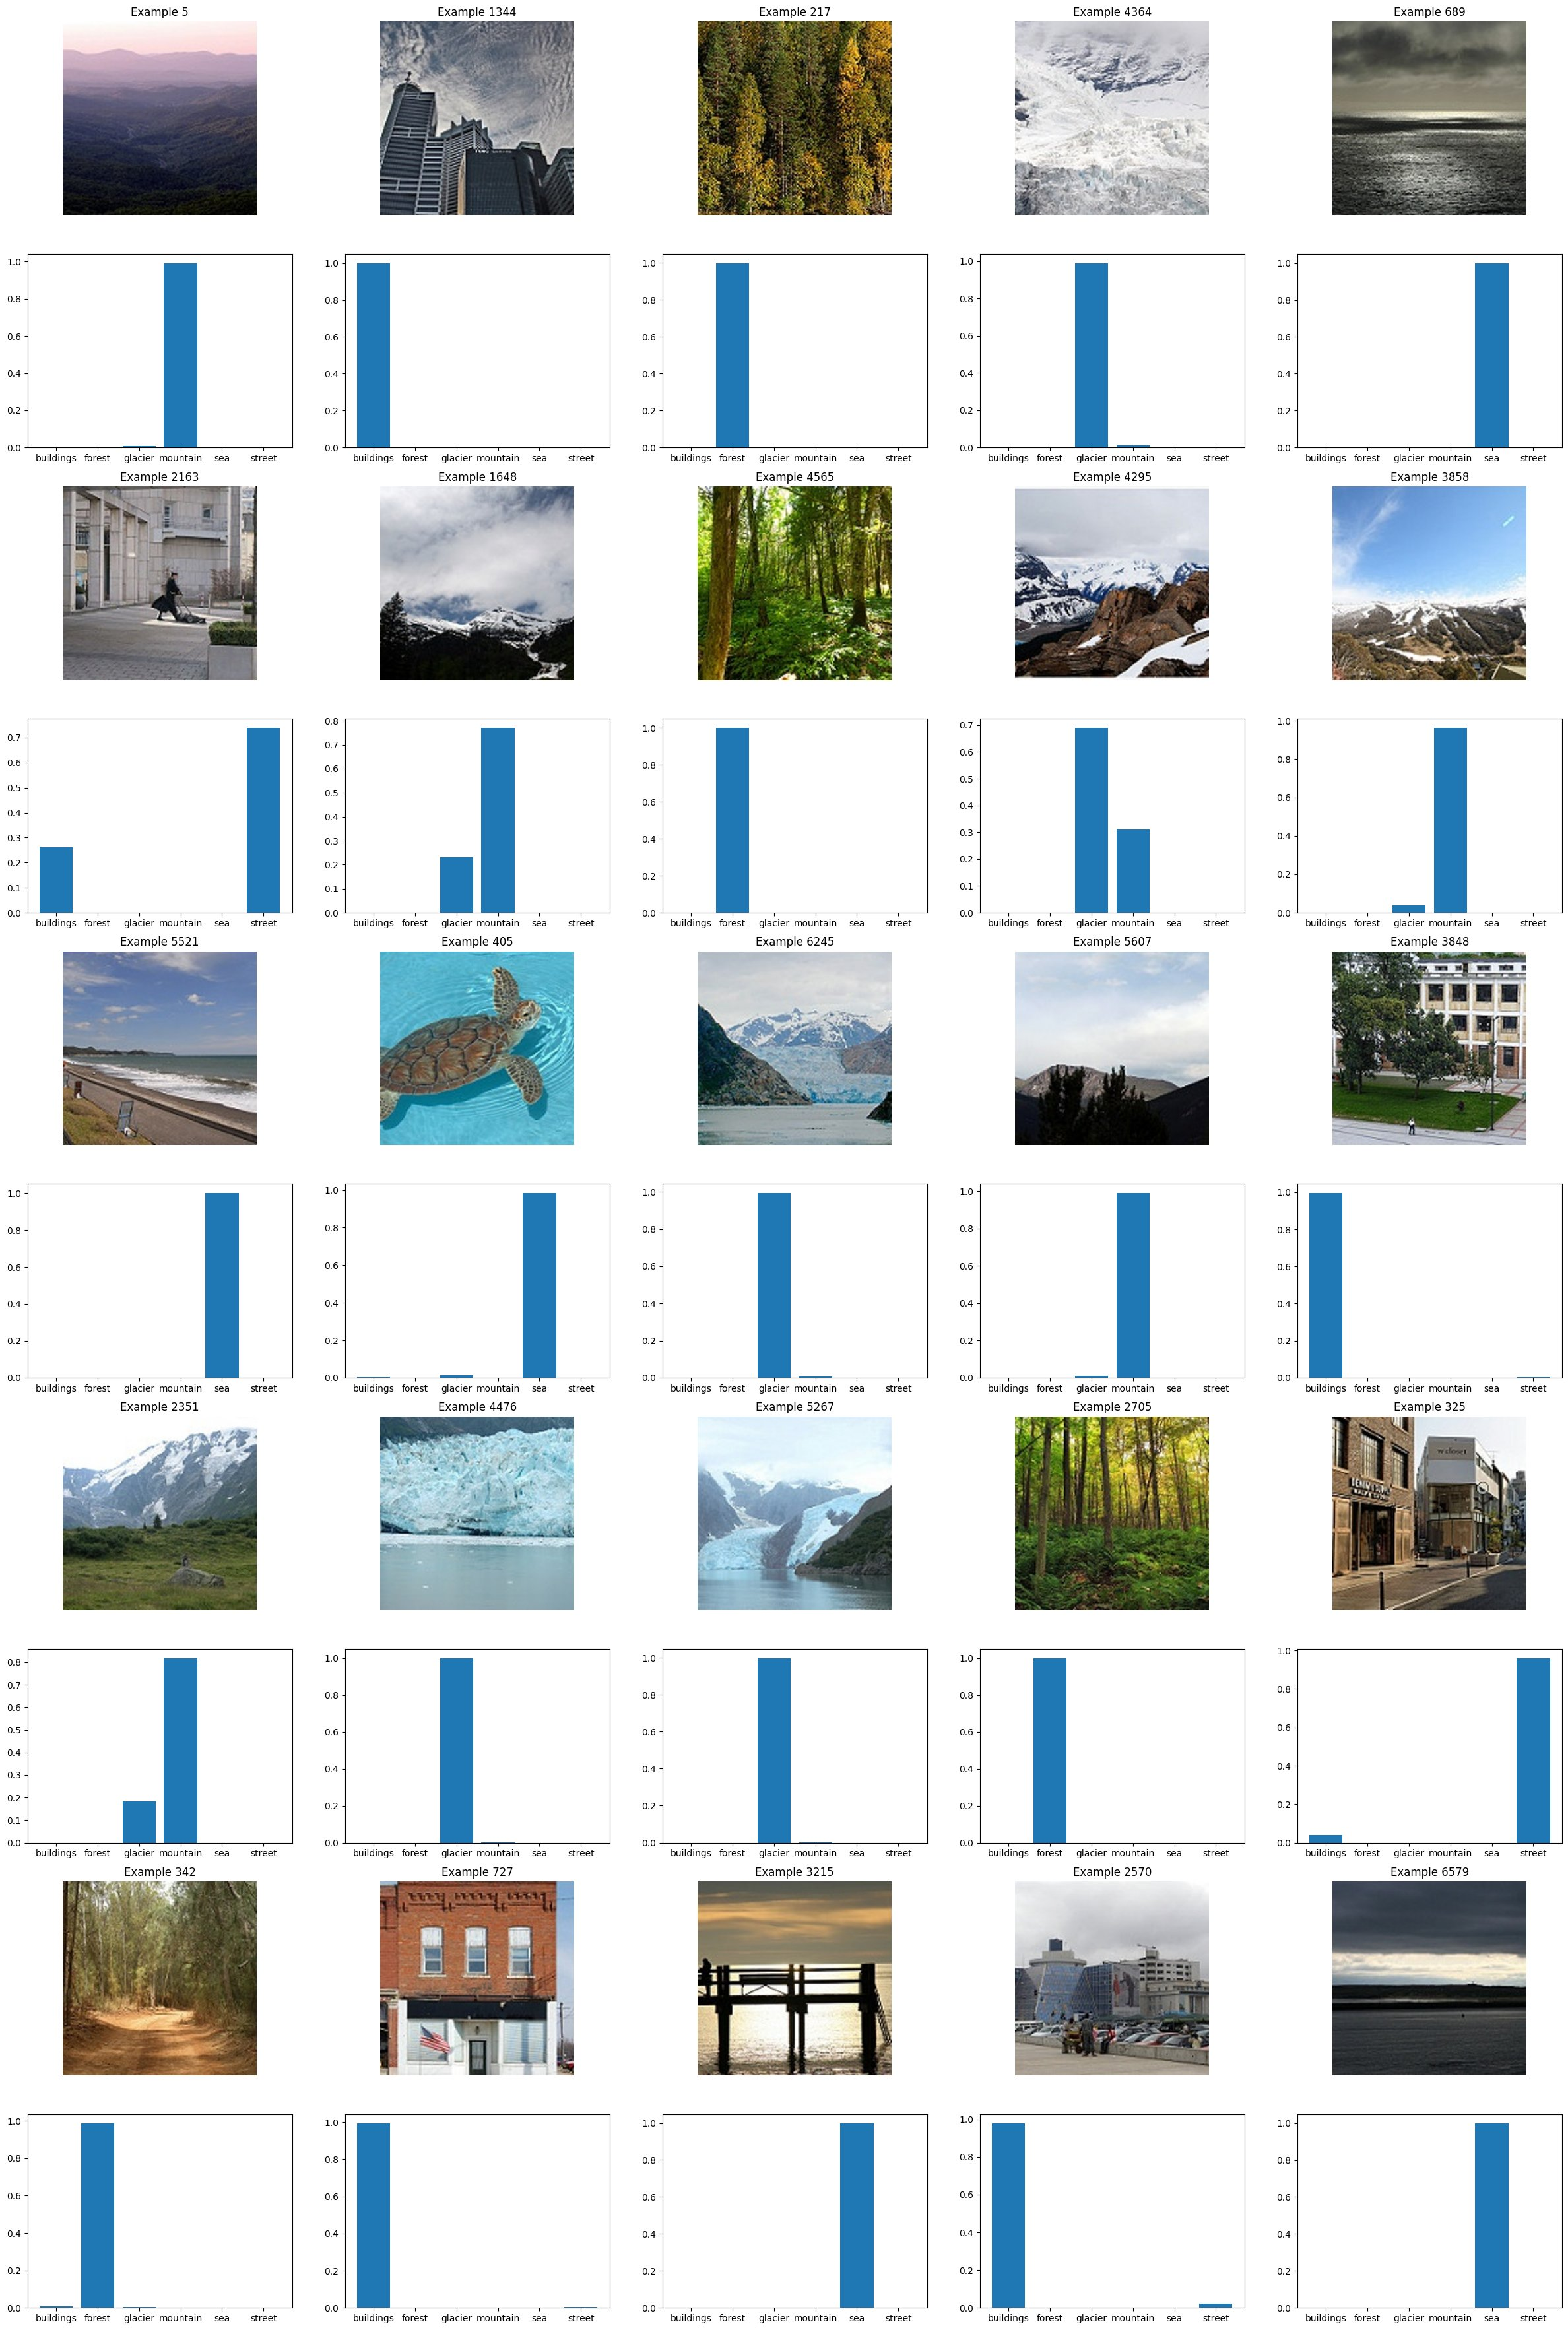

In [32]:
# Create the grid of subplots. We pass the figsize argument to enlarge
# the figure, which is small by default
_, ax = plt.subplots(10, 5, figsize=(30, 45))

# Pick 25 random indices, without replacement (we don't want to display the
# same image twice)
random_indexes = numpy.random.choice(pred_images.shape[0],
                                     size=(5, 5),
                                     replace=False)

for i in range(5):
  for j in range(5):
    img_index = random_indexes[i, j]
    # Get the image and predict its class
    image = pred_images[img_index]
    probabilities = transferred_transformer.predict(image[None, ...])[0]
    predicted_class = label_names[numpy.argmax(probabilities)]

    # Display with matplotlib and its imshow function, very handy in computer
    # vision
    ax[i * 2, j].imshow(tf.transpose(image, perm=(1, 2, 0)))
    ax[i * 2, j].set_title(f"Example {img_index}")
    ax[i * 2, j].axis('off')

    # Display the prediction distribution on the row below
    ax[i * 2 + 1, j].bar(label_names, probabilities)

## Occlusion Analysis

In [33]:
images, labels = get_images(pathlib.Path("landscape") / "seg_train")

Processing folders:   0%|          | 0/6 [00:00<?, ?it/s]

Folder buildings:   0%|          | 0/2191 [00:00<?, ?it/s]

Folder forest:   0%|          | 0/2271 [00:00<?, ?it/s]

Folder glacier:   0%|          | 0/2404 [00:00<?, ?it/s]

Folder mountain:   0%|          | 0/2512 [00:00<?, ?it/s]

Folder sea:   0%|          | 0/2274 [00:00<?, ?it/s]

Folder street:   0%|          | 0/2382 [00:00<?, ?it/s]

True class: street
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Probability of the right class with the full image: 0.88932276


  0%|          | 0/169 [00:00<?, ?it/s]

6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 526ms/step


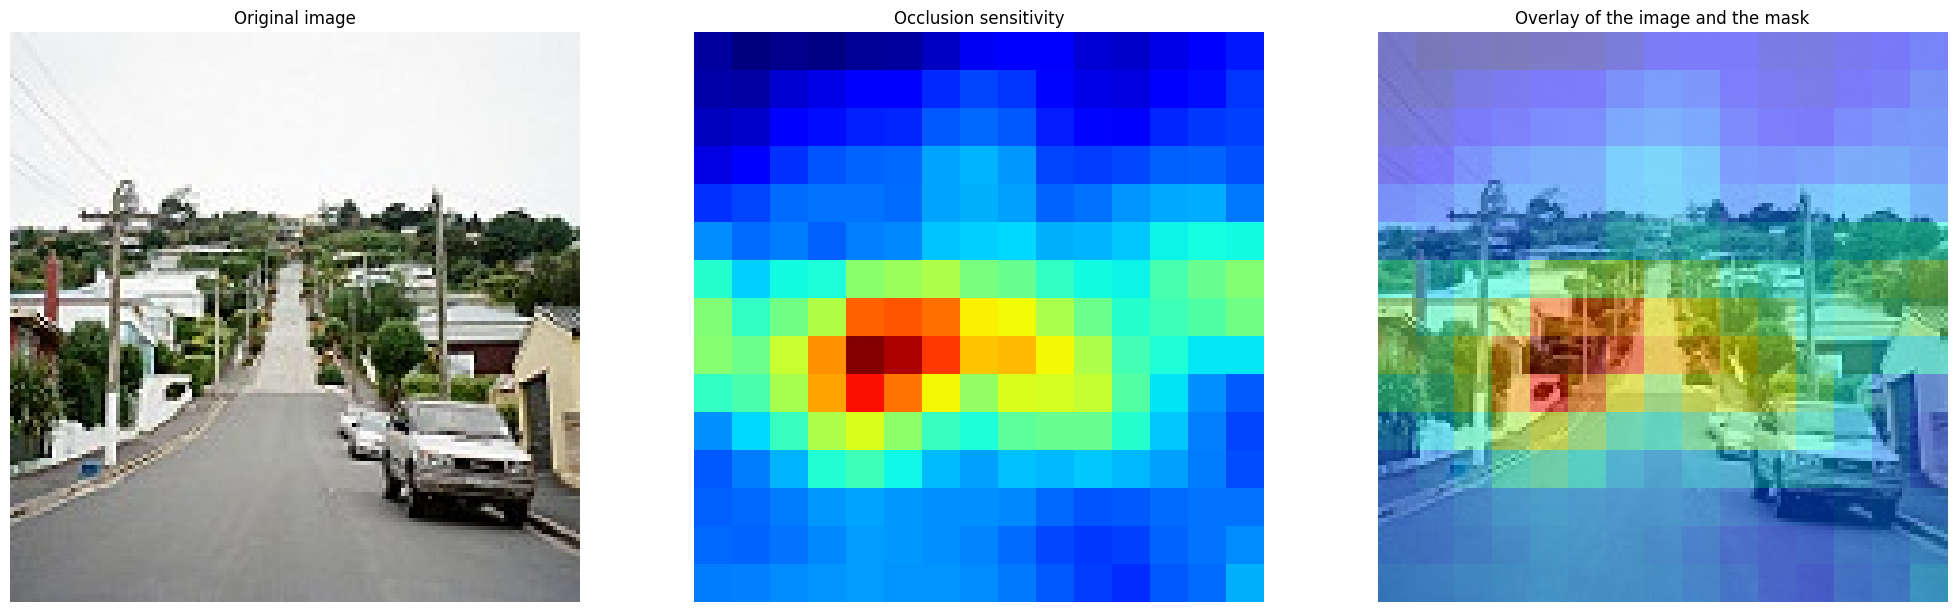

In [34]:
def occlusion_analysis(image: tf.Tensor,
                       label: int,
                       size: int = 30,
                       step: int = 10
                       ) -> None:
  print("True class:", label_names[label])
  label_prob_full = deep_cnn.predict(image[None, ...])[0, label]
  print("Probability of the right class with the full image:",
        label_prob_full)
  height, width = image.shape[:2]
  n_height = image.shape[0] - size + 1
  n_width = image.shape[1] - size + 1
  occluded_images = []
  mask = tf.cast(tf.fill(image.shape, 127), tf.uint8)
  ones = tf.ones(size, dtype="uint8")
  ii = list(range(0, n_height, step))
  jj = list(range(0, n_width, step))
  for i, j in tqdm.notebook.tqdm(list(itertools.product(ii, jj)), leave=False):
    indices_height = tf.pad(ones, [[i, height - size - i]])
    indices_width = tf.pad(ones, [[j, width - size - j]])
    indices = (indices_height[:, None] * indices_width[None, :])[..., None]
    occluded_images.append(tf.where(tf.cast(indices, tf.bool), mask, image))
  weights = tf.nn.conv2d_transpose(tf.ones((1, len(ii), len(jj), 1)),
                                   tf.ones((size, size, 1, 1)),
                                   (1, *image.shape[:2], 1),
                                   step,
                                   padding="VALID")
  occluded_images_tensor = tf.stack(occluded_images)
  preds = deep_cnn.predict(occluded_images_tensor).reshape(len(ii), len(jj), -1)
  label_preds = preds[None, ..., label, None]
  heatmap = tf.nn.conv2d_transpose(label_preds,
                                   tf.ones((size, size, 1, 1)),
                                   (1, *image.shape[:2], 1),
                                   step,
                                   padding="VALID")
  heatmap /= weights
  heatmap *= -1
  heatmap -= numpy.min(heatmap)
  heatmap /= numpy.max(heatmap)
  heatmap *= 255

  heatmap = numpy.array(heatmap).astype(numpy.uint8)[0,:,:,:]
  # Use jet colormap to colorize heatmap
  jet = matplotlib.colormaps["jet"]

  # Use RGB values of the colormap
  jet_colors = jet(numpy.arange(256))[:, :3]
  jet_heatmap = jet_colors[heatmap][:,:,0,:]
  # Create an image with RGB colorized heatmap
  jet_heatmap = skimage.transform.resize(jet_heatmap, (image.shape[0], image.shape[1]))


  fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(25, 8))
  ax1.imshow(image)
  ax1.axis("off")
  ax1.set_title("Original image")
  ax2.imshow(jet_heatmap)
  ax2.axis("off")
  ax2.set_title("Occlusion sensitivity")
  #ax3.imshow(superimposed_img)
  ax3.imshow(image)
  ax3.imshow(jet_heatmap, alpha = 0.5)
  ax3.axis("off")
  ax3.set_title("Overlay of the image and the mask")
  plt.show()


i = 600
occlusion_analysis(images[i], labels[i])

## Key takeaways

Accuracy on the validation set in a full run (`SHORT_RUN = False`) on a T4. The short version gives lower scores.

| Model | Training | Accuracy (validation) |
| --- | --- | --- |
| Minimalistic CNN (1 convolution) | from scratch, 1 epoch | 22–26% |
| Deep CNN (6 convolutions) | from scratch, 15 epochs | 84% |
| EfficientNetV2B0 pretrained on ImageNet | transfer, 5 epochs | 90% |
| ViT pretrained on ImageNet-21k | transfer, 3 epochs | 94% |

- Chance would give about 17% (6 classes): the minimalistic CNN barely learns. The depth of the network matters.
- Training a deep network from scratch is expensive: it is the longest step of this notebook, and it needs many images.
- Transfer learning reuses a model already trained on millions of images and only trains the added layers: in a few epochs, it does better. It is the default starting point of a computer vision project.
- The remaining errors are often between close classes, such as glacier and mountain: the confusion matrix and the misclassified images show it, and some of these images are ambiguous even for a human.
- The occlusion analysis shows which areas of the image matter for the prediction: a simple way to check that the model looks at the right place.